# Surprisal Analysis Notebook

Two parallel analyses for each experiment × model combination:
- **Independent**: every sentence treated as its own observation
- **Paired**: sentences grouped by item (`subkind` × `number`), respecting the Latin-square / repeated-measures structure

Human comparison framework included as a placeholder — fill in `HUMAN_DATA_PATH` when ratings are available.

In [1]:
import os
import json
import glob
import numpy as np
import pandas as pd
import scipy.stats as stats
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from itertools import combinations

RESULTS_DIR = "results"
CSV_DIR     = "csvs"
PLOT_DIR    = "plots"
os.makedirs(PLOT_DIR, exist_ok=True)

# Path to human acceptability ratings CSV when available.
# Expected columns: experiment, subkind, number, variant, mean_rating (1-7 Likert)
HUMAN_DATA_PATH = None  # e.g. "human_ratings.csv"

sns.set_theme(style="whitegrid", palette="muted")

df_raw = load_all_results(RESULTS_DIR, CSV_DIR)

# --- item_id assignment ---
#
# Exp 2 & 3: subkind × number already uniquely identifies one sentence per variant.
# Exp 1:  subkind × number has TWO sentences per variant (Latin-square counterbalancing
#         with different celebrities). Sorting alphabetically by sentence within each
#         subkind × number × variant block aligns celebrities across CP and PP, so
#         pair_sub_index 0 is always the same celebrity in both variants.
#         Result: each item_id maps to exactly one CP and one PP sentence — same
#         structure as exp 3 (just without the Co variant).
#
# To fall back to number-only grouping for exp1 (averaging over the two celebrities),
# comment out the exp1 block below and uncomment the single line at the bottom.

def build_item_ids(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    exp1 = df[df["experiment"] == 1].copy()
    rest = df[df["experiment"] != 1].copy()

    # Exp 1: alphabetical sort within block → assign pair_sub_index
    exp1 = exp1.sort_values(["subkind", "number", "variant", "sentence"])
    exp1["pair_sub_index"] = (
        exp1.groupby(["subkind", "number", "variant"]).cumcount()
    )
    exp1["item_id"] = (
        exp1["subkind"].astype(str) + "_"
        + exp1["number"].astype(str) + "_"
        + exp1["pair_sub_index"].astype(str)
    )

    # Exp 2 & 3: number already uniquely identifies the item
    rest["item_id"] = rest["subkind"].astype(str) + "_" + rest["number"].astype(str)

    # # Alternative for exp1 — number-only (averages over celebrity pairs):
    # exp1["item_id"] = exp1["subkind"].astype(str) + "_" + exp1["number"].astype(str)

    return pd.concat([exp1, rest], ignore_index=True)


df_raw = build_item_ids(df_raw)

print(f"Loaded {len(df_raw):,} rows across {df_raw['model'].nunique()} models "
      f"and {df_raw['experiment'].nunique()} experiments.")

# Sanity check: exp1 items should each have exactly 1 CP and 1 PP sentence
exp1_check = (
    df_raw[df_raw["experiment"] == 1]
    .groupby(["item_id", "variant"])
    .size()
    .unstack(fill_value=0)
)
assert (exp1_check == 1).all().all(), "Exp1 item pairing is not 1:1 — check sort logic."
print("Exp1 item pairing check passed.")
df_raw.head()

In [2]:
STIM_COLS = {
    1: ["kind", "subkind", "variant", "number", "sentence"],
    2: ["code", "kind", "subkind", "variant", "number", "C1", "C2", "D1", "D2", "sentence"],
    3: ["code", "kind", "subkind", "variant", "number",
        "CFU_1", "CFU_2", "CFU_3", "DFU_1", "DFU_2", "DFU_3", "sentence"],
}

def load_all_results(results_dir: str, csv_dir: str) -> pd.DataFrame:
    frames = []
    for exp_num in [1, 2, 3]:
        stim = pd.read_csv(
            os.path.join(csv_dir, f"exp{exp_num}_ST.csv"), index_col=0
        ).reset_index(drop=True)

        pattern = os.path.join(results_dir, f"results_exp{exp_num}_*.csv")
        for path in sorted(glob.glob(pattern)):
            model_id = (
                os.path.basename(path)
                .replace(f"results_exp{exp_num}_", "")
                .replace(".csv", "")
                .replace("_", "/", 1)   # restore first slash only (org/model)
            )
            df = pd.read_csv(path)
            df["model"]      = model_id
            df["experiment"] = exp_num
            frames.append(df)

    if not frames:
        raise FileNotFoundError("No result files found in results/. Run the pipeline first.")

    return pd.concat(frames, ignore_index=True)


df_raw = load_all_results(RESULTS_DIR, CSV_DIR)

# item_id uniquely identifies one stimulus content block across variants
df_raw["item_id"] = df_raw["subkind"].astype(str) + "_" + df_raw["number"].astype(str)

print(f"Loaded {len(df_raw):,} rows across {df_raw['model'].nunique()} models "
      f"and {df_raw['experiment'].nunique()} experiments.")
df_raw.head()

Loaded 3,652 rows across 11 models and 3 experiments.


,kind,subkind,variant,number,sentence,tokens,token_surprisals,sentence_surprisal,mean_surprisal,num_tokens,...,C2,D1,D2,CFU_1,CFU_2,CFU_3,DFU_1,DFU_2,DFU_3,item_id
0,STIMULUS,DEPEND,CP,1,DiCaprio can depend that his reputation is unm...,"[""Cap"", ""rio"", ""\u0120can"", ""\u0120depend"", ""\...","[9.4296875, 0.142578125, 6.7734375, 10.0859375...",57.974609,4.831217,12,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,DEPEND_1
1,STIMULUS,DEPEND,CP,1,Justin Bieber can depend that his fans still l...,"[""\u0120Bieber"", ""\u0120can"", ""\u0120depend"", ...","[4.39453125, 5.98046875, 9.3671875, 7.8125, 1....",53.565918,4.463826,12,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,DEPEND_1
2,STIMULUS,DEPEND,CP,2,Beyoncé should depend that her albums typicall...,"[""ey"", ""onc\u00c3\u00a9"", ""\u0120should"", ""\u0...","[5.03125, 1.513671875, 10.0859375, 11.0546875,...",66.227051,4.730504,14,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,DEPEND_2
3,STIMULUS,DEPEND,CP,2,Zendaya can depend that her stylist is experie...,"[""aya"", ""\u0120can"", ""\u0120depend"", ""\u0120th...","[4.6796875, 6.59375, 17.359375, 6.6875, 1.9912...",67.627441,5.202111,13,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,DEPEND_2
4,STIMULUS,DEPEND,CP,3,Our parents can depend that we already attaine...,"[""\u0120parents"", ""\u0120can"", ""\u0120depend"",...","[5.671875, 4.51171875, 8.7265625, 8.0, 1.52734...",59.166016,5.916602,10,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,DEPEND_3


## 2. Preprocessing

Drop failed rows, then compute:
- **z-scored surprisal** — per model × experiment, zero-meaned and unit-variance
- **quasi-Likert (percentile)** — inverted percentile rank mapped to [1, 7]; robust to outliers
- **quasi-Likert (probability)** — `exp(-surprisal)` rescaled to [1, 7]; information-theoretically grounded

In [3]:
df = df_raw[df_raw["error"].isna() & df_raw["sentence_surprisal"].notna()].copy()
n_dropped = len(df_raw) - len(df)
if n_dropped:
    print(f"Dropped {n_dropped} rows with errors.")

def z_score_group(series):
    return (series - series.mean()) / series.std(ddof=1)

def percentile_likert(series, lo=1, hi=7):
    """Higher surprisal → lower acceptability, so we invert the percentile."""
    pct = series.rank(pct=True)           # 0..1, higher = more surprising
    inverted = 1 - pct                    # higher = less surprising = more acceptable
    return lo + inverted * (hi - lo)

def prob_likert(series, lo=1, hi=7):
    """Map exp(-surprisal) ∈ (0,1] linearly onto [lo, hi]."""
    p = np.exp(-series)
    p_min, p_max = p.min(), p.max()
    if p_max == p_min:
        return pd.Series(np.full(len(series), (lo + hi) / 2), index=series.index)
    return lo + (p - p_min) / (p_max - p_min) * (hi - lo)

grp = df.groupby(["model", "experiment"])["sentence_surprisal"]
df["surprisal_z"]          = grp.transform(z_score_group)
df["quasi_likert_pct"]     = grp.transform(percentile_likert)
df["quasi_likert_prob"]    = grp.transform(prob_likert)

print(df[["sentence_surprisal", "surprisal_z",
          "quasi_likert_pct", "quasi_likert_prob"]].describe().round(3))

       sentence_surprisal  surprisal_z  quasi_likert_pct  quasi_likert_prob
count            3652.000     3652.000          3652.000           3652.000
mean               62.657        0.000             3.973              1.079
std                11.220        0.996             1.732              0.627
min                32.473       -3.298             1.000              1.000
25%                55.257       -0.640             2.488              1.000
50%                61.745       -0.095             3.977              1.000
75%                69.595        0.604             5.465              1.000
max               107.495        3.828             6.953              7.000


## 3. Independent analysis

Every sentence is its own observation. Tests: Kruskal-Wallis (omnibus) → pairwise Wilcoxon with Holm correction.

In [4]:
from statsmodels.stats.multitest import multipletests

def independent_analysis(df: pd.DataFrame, metric: str = "sentence_surprisal") -> pd.DataFrame:
    records = []
    for (model, exp), gdf in df.groupby(["model", "experiment"]):
        variants = sorted(gdf["variant"].unique())
        groups   = [gdf.loc[gdf["variant"] == v, metric].dropna() for v in variants]

        # Omnibus
        if len(groups) >= 2:
            kw_stat, kw_p = stats.kruskal(*groups)
        else:
            kw_stat, kw_p = np.nan, np.nan

        # Pairwise
        pairs   = list(combinations(range(len(variants)), 2))
        raw_ps  = [stats.mannwhitneyu(groups[i], groups[j],
                                      alternative="two-sided").pvalue
                   for i, j in pairs]
        if raw_ps:
            _, adj_ps, _, _ = multipletests(raw_ps, method="holm")
        else:
            adj_ps = []

        # Descriptives
        for v, g in zip(variants, groups):
            records.append({
                "model":      model,
                "experiment": exp,
                "variant":    v,
                "n":          len(g),
                "mean":       g.mean(),
                "sd":         g.std(ddof=1),
                "median":     g.median(),
                "kw_stat":    kw_stat,
                "kw_p":       kw_p,
            })

        for (i, j), adj_p in zip(pairs, adj_ps):
            records[-len(variants) + i][f"p_vs_{variants[j]}_holm"] = adj_p

    return pd.DataFrame(records)


indep_results = independent_analysis(df)
indep_results.round(4).head(20)

,model,experiment,variant,n,mean,sd,median,kw_stat,kw_p,p_vs_PP_holm,p_vs_NC_holm,p_vs_Co_holm
0,Qwen/Qwen2.5-1.5B,1,CP,64,61.7134,10.4914,60.4933,0.2798,0.5968,0.5985,NaN,NaN
1,Qwen/Qwen2.5-1.5B,1,PP,64,60.7011,9.8683,59.5083,0.2798,0.5968,NaN,NaN,NaN
2,Qwen/Qwen2.5-1.5B,2,C,48,63.2396,13.1704,61.5169,6.5775,0.0103,NaN,0.0104,NaN
3,Qwen/Qwen2.5-1.5B,2,NC,48,55.6019,12.0254,55.9229,6.5775,0.0103,NaN,NaN,NaN
4,Qwen/Qwen2.5-1.5B,3,CP,36,62.6673,9.3866,63.3179,4.8936,0.0866,0.1405,NaN,0.1413
5,Qwen/Qwen2.5-1.5B,3,Co,36,66.4542,9.3057,66.7308,4.8936,0.0866,0.8350,NaN,NaN
6,Qwen/Qwen2.5-1.5B,3,PP,36,67.0188,9.3457,66.8314,4.8936,0.0866,NaN,NaN,NaN
7,Qwen/Qwen2.5-72B,1,CP,64,59.4421,9.3795,60.5627,0.5316,0.4659,0.4674,NaN,NaN
8,Qwen/Qwen2.5-72B,1,PP,64,58.5366,9.4561,58.4823,0.5316,0.4659,NaN,NaN,NaN
9,Qwen/Qwen2.5-72B,2,C,48,61.9614,12.5853,59.5092,5.5672,0.0183,NaN,0.0185,NaN


## 4. Paired analysis

Sentences are grouped by **item** (`subkind` × `number`). Exp 1 has two sentences per item×variant (Latin square), so we aggregate to item means first. Tests: Wilcoxon signed-rank on item-level means (non-parametric paired test), plus a linear mixed-effects model with item as a random intercept for the full picture.

In [5]:
def paired_analysis(df: pd.DataFrame, metric: str = "sentence_surprisal") -> pd.DataFrame:
    records = []
    for (model, exp), gdf in df.groupby(["model", "experiment"]):
        variants = sorted(gdf["variant"].unique())

        # Aggregate to item level (handles exp1's 2-sentence-per-cell structure)
        item_means = (
            gdf.groupby(["item_id", "variant"])[metric]
            .mean()
            .reset_index()
            .pivot(index="item_id", columns="variant", values=metric)
            .dropna()
        )

        for v1, v2 in combinations(variants, 2):
            if v1 not in item_means or v2 not in item_means:
                continue
            a, b    = item_means[v1], item_means[v2]
            w_stat, w_p = stats.wilcoxon(a, b, alternative="two-sided")
            d       = (a - b).mean() / (a - b).std(ddof=1)  # Cohen's d on differences
            records.append({
                "model":        model,
                "experiment":   exp,
                "variant_A":    v1,
                "variant_B":    v2,
                "mean_A":       a.mean(),
                "mean_B":       b.mean(),
                "mean_diff":    (a - b).mean(),
                "cohens_d":     d,
                "wilcoxon_W":   w_stat,
                "wilcoxon_p":   w_p,
                "n_items":      len(a),
            })

    return pd.DataFrame(records)


paired_results = paired_analysis(df)
paired_results.round(4).head(20)

,model,experiment,variant_A,variant_B,mean_A,mean_B,mean_diff,cohens_d,wilcoxon_W,wilcoxon_p,n_items
0,Qwen/Qwen2.5-1.5B,1,CP,PP,61.7134,60.7011,1.0123,0.3283,180.0,0.1195,32
1,Qwen/Qwen2.5-1.5B,2,C,NC,63.2396,55.6019,7.6378,1.1707,34.0,0.0000,48
2,Qwen/Qwen2.5-1.5B,3,CP,Co,62.6673,66.4542,-3.7870,-0.9742,82.0,0.0000,36
3,Qwen/Qwen2.5-1.5B,3,CP,PP,62.6673,67.0188,-4.3516,-1.0313,55.0,0.0000,36
4,Qwen/Qwen2.5-1.5B,3,Co,PP,66.4542,67.0188,-0.5646,-0.2492,250.0,0.1974,36
5,Qwen/Qwen2.5-72B,1,CP,PP,59.4421,58.5366,0.9055,0.3045,158.0,0.0475,32
6,Qwen/Qwen2.5-72B,2,C,NC,61.9614,55.0347,6.9267,0.9901,72.0,0.0000,48
7,Qwen/Qwen2.5-72B,3,CP,Co,60.3551,64.5032,-4.1481,-0.9930,43.0,0.0000,36
8,Qwen/Qwen2.5-72B,3,CP,PP,60.3551,64.3830,-4.0280,-1.0440,38.0,0.0000,36
9,Qwen/Qwen2.5-72B,3,Co,PP,64.5032,64.3830,0.1201,0.0674,310.0,0.7269,36


In [6]:
def mixed_effects_analysis(df: pd.DataFrame,
                            metric: str = "sentence_surprisal") -> pd.DataFrame:
    """
    Linear mixed-effects model: metric ~ variant + (1 | item_id)
    Reference level for variant is the first variant alphabetically.
    Returns a summary row per model × experiment × variant coefficient.
    """
    records = []
    for (model, exp), gdf in df.groupby(["model", "experiment"]):
        gdf = gdf[["item_id", "variant", metric]].dropna().copy()
        gdf["variant"] = pd.Categorical(gdf["variant"],
                                        categories=sorted(gdf["variant"].unique()))
        try:
            lme = smf.mixedlm(f"{metric} ~ variant", data=gdf,
                              groups=gdf["item_id"]).fit(reml=True)
            for term, coef, se, p in zip(
                lme.params.index, lme.params, lme.bse, lme.pvalues
            ):
                records.append({
                    "model":      model,
                    "experiment": exp,
                    "term":       term,
                    "coef":       coef,
                    "se":         se,
                    "p":          p,
                    "converged":  lme.converged,
                })
        except Exception as e:
            records.append({"model": model, "experiment": exp,
                            "term": "ERROR", "coef": None,
                            "se": None, "p": None,
                            "converged": False, "note": str(e)})
    return pd.DataFrame(records)


lme_results = mixed_effects_analysis(df)
lme_results.round(4).head(20)

,model,experiment,term,coef,se,p,converged
0,Qwen/Qwen2.5-1.5B,1,Intercept,61.7134,1.5810,0.0000,True
1,Qwen/Qwen2.5-1.5B,1,variant[T.PP],-1.0123,1.2404,0.4144,True
2,Qwen/Qwen2.5-1.5B,1,Group Var,1.1247,0.4021,0.0052,True
3,Qwen/Qwen2.5-1.5B,2,Intercept,63.2396,1.8202,0.0000,True
4,Qwen/Qwen2.5-1.5B,2,variant[T.NC],-7.6378,0.9417,0.0000,True
5,Qwen/Qwen2.5-1.5B,2,Group Var,6.4729,2.0342,0.0015,True
6,Qwen/Qwen2.5-1.5B,3,Intercept,62.6673,1.5577,0.0000,True
7,Qwen/Qwen2.5-1.5B,3,variant[T.Co],3.7870,0.5935,0.0000,True
8,Qwen/Qwen2.5-1.5B,3,variant[T.PP],4.3516,0.5935,0.0000,True
9,Qwen/Qwen2.5-1.5B,3,Group Var,12.7743,3.8375,0.0009,True


## 5. Human comparison framework

When human ratings are available, this section computes:
- **Spearman ρ** between surprisal and mean human rating per item × variant
- **Z-score overlay** — both measures on the same scale for plotting
- **Quasi-Likert overlay** — percentile-based conversion alongside human Likert means

In [7]:
if HUMAN_DATA_PATH and os.path.exists(HUMAN_DATA_PATH):
    human = pd.read_csv(HUMAN_DATA_PATH)
    # Expected columns: experiment, subkind, number, variant, mean_rating
    human["item_id"] = human["subkind"].astype(str) + "_" + human["number"].astype(str)
    human["rating_z"] = (
        human.groupby("experiment")["mean_rating"]
        .transform(z_score_group)
    )

    # Per model: Spearman r between item-level mean surprisal and human rating
    corr_records = []
    for (model, exp), gdf in df.groupby(["model", "experiment"]):
        item_surprisal = (
            gdf.groupby(["item_id", "variant"])["sentence_surprisal"]
            .mean().reset_index()
        )
        merged = item_surprisal.merge(
            human[human["experiment"] == exp][["item_id", "variant", "mean_rating"]],
            on=["item_id", "variant"], how="inner"
        )
        if len(merged) < 5:
            continue
        rho, p = stats.spearmanr(merged["sentence_surprisal"], merged["mean_rating"])
        corr_records.append({"model": model, "experiment": exp,
                              "spearman_rho": rho, "p": p, "n": len(merged)})

    human_corr = pd.DataFrame(corr_records).sort_values("spearman_rho", ascending=False)
    display(human_corr.round(3))
else:
    print("No human data loaded. Set HUMAN_DATA_PATH to enable this section.")
    human_corr = None

No human data loaded. Set HUMAN_DATA_PATH to enable this section.


## 6. Visualisation

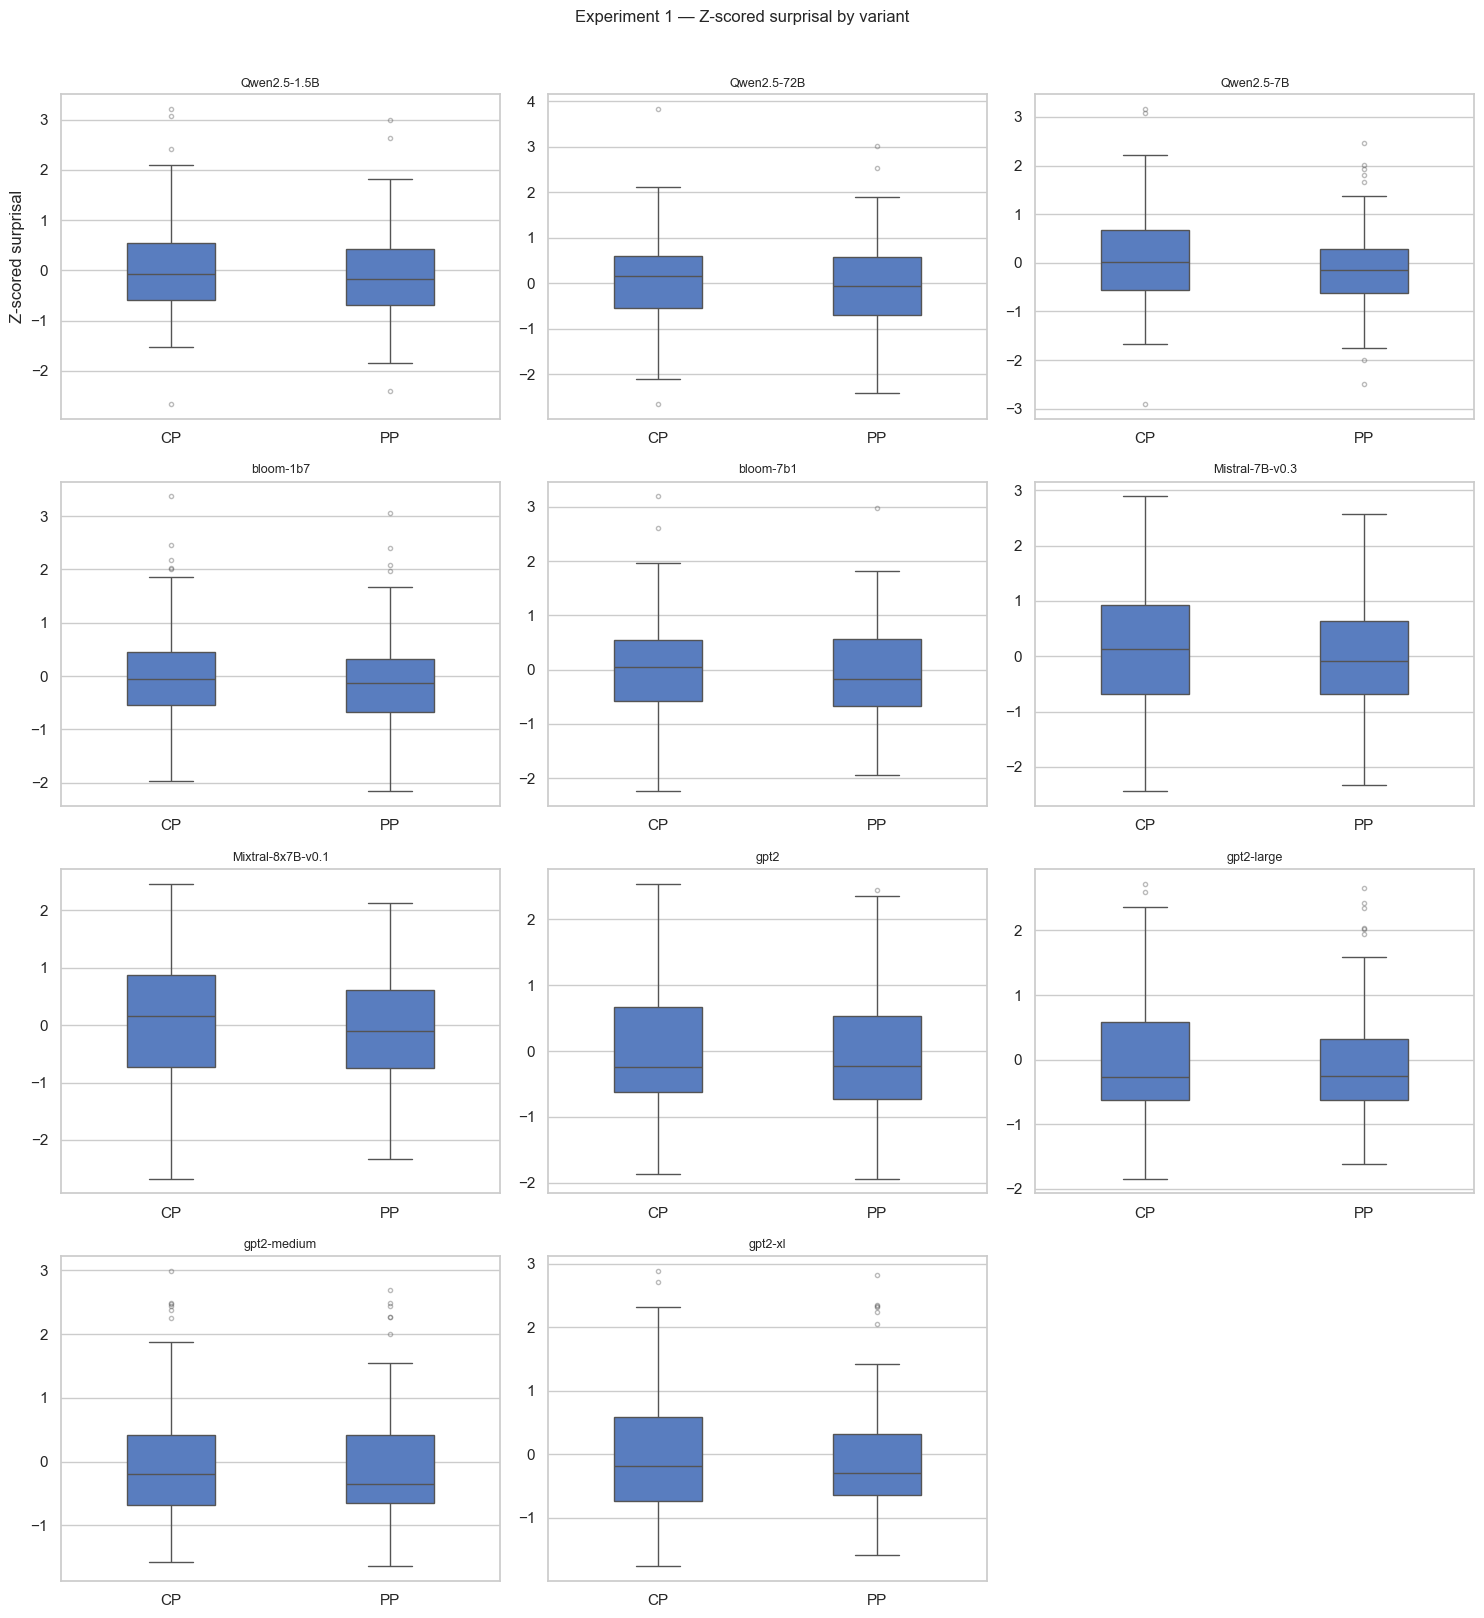

Saved: plots\exp1_surprisal_z_by_variant.png


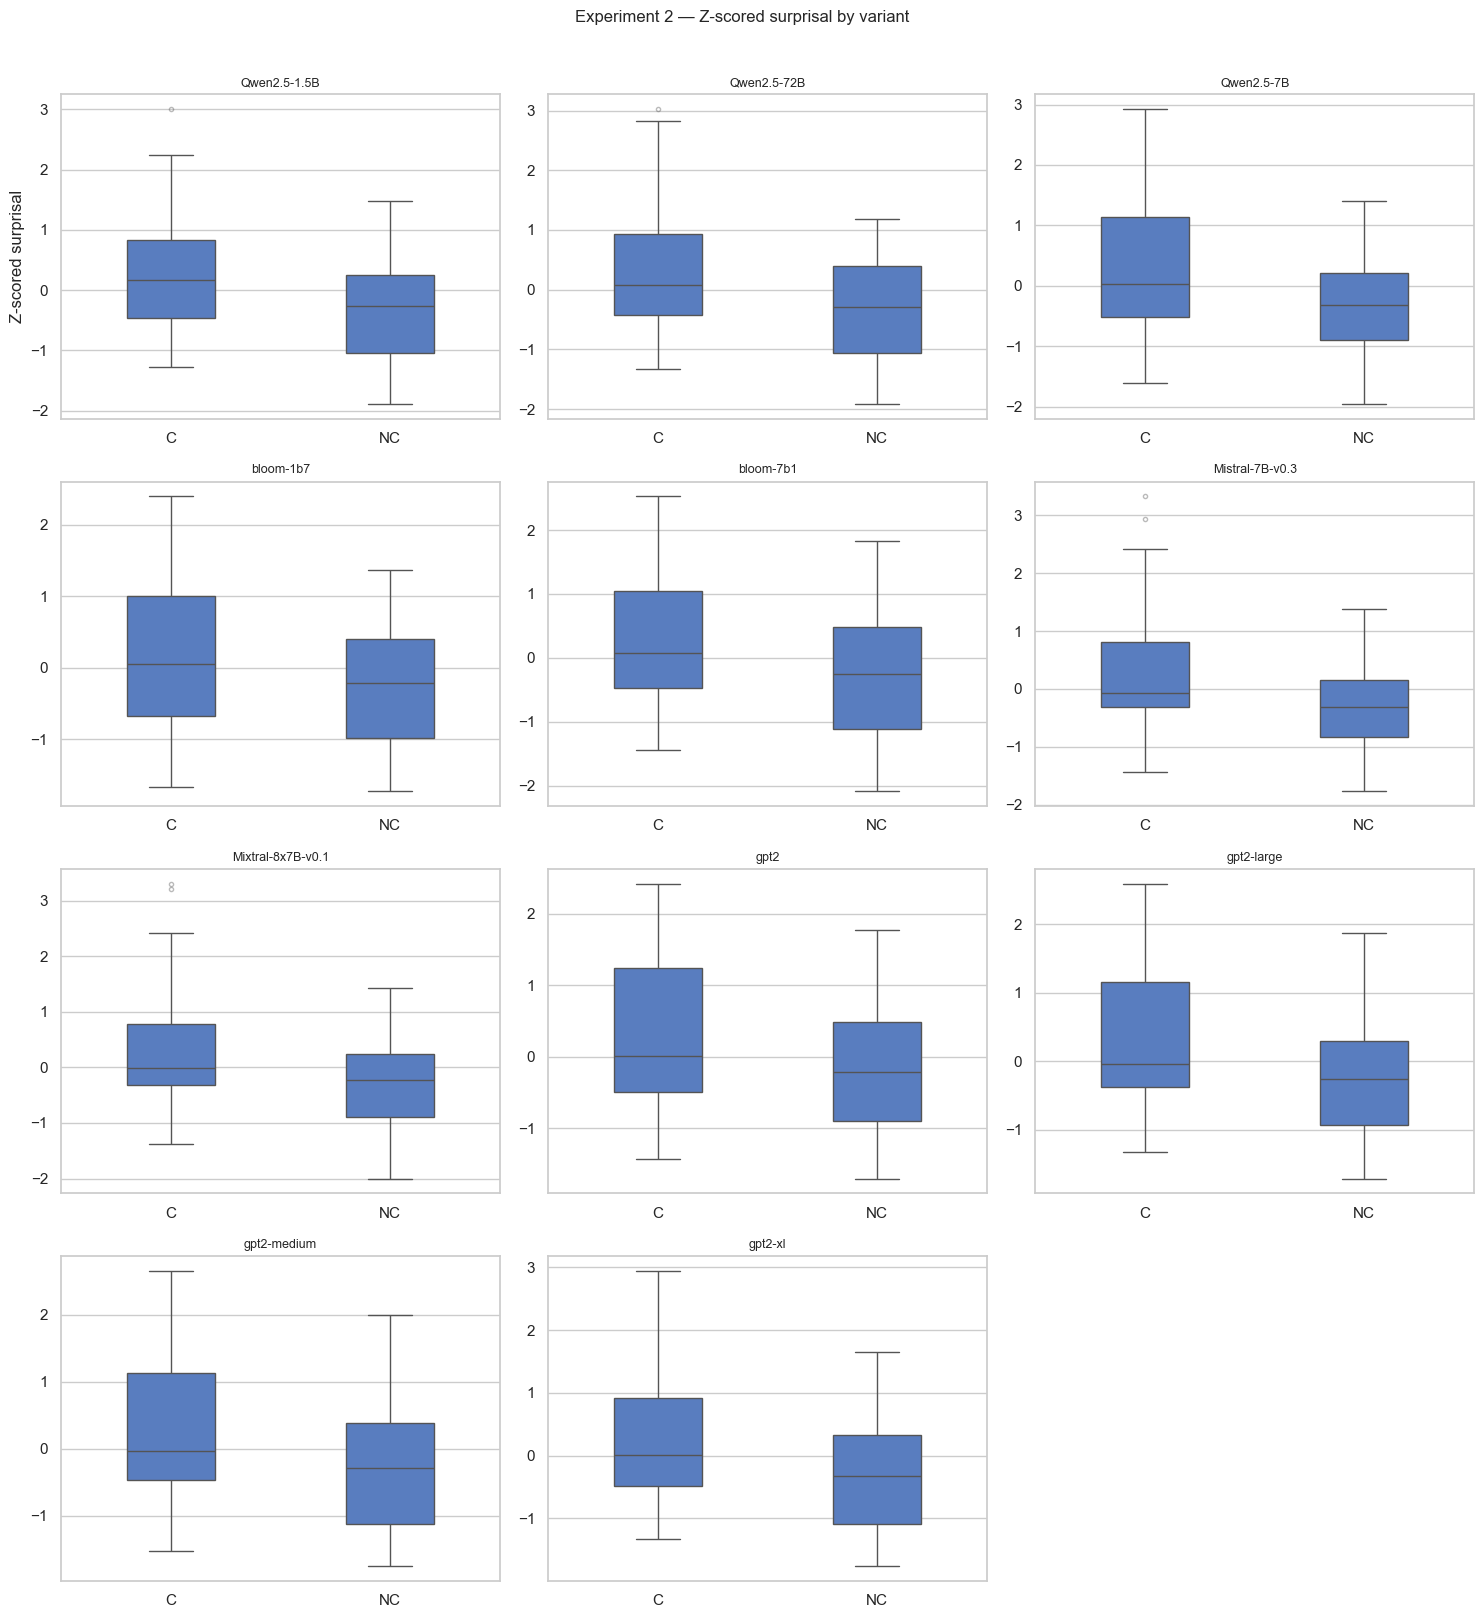

Saved: plots\exp2_surprisal_z_by_variant.png


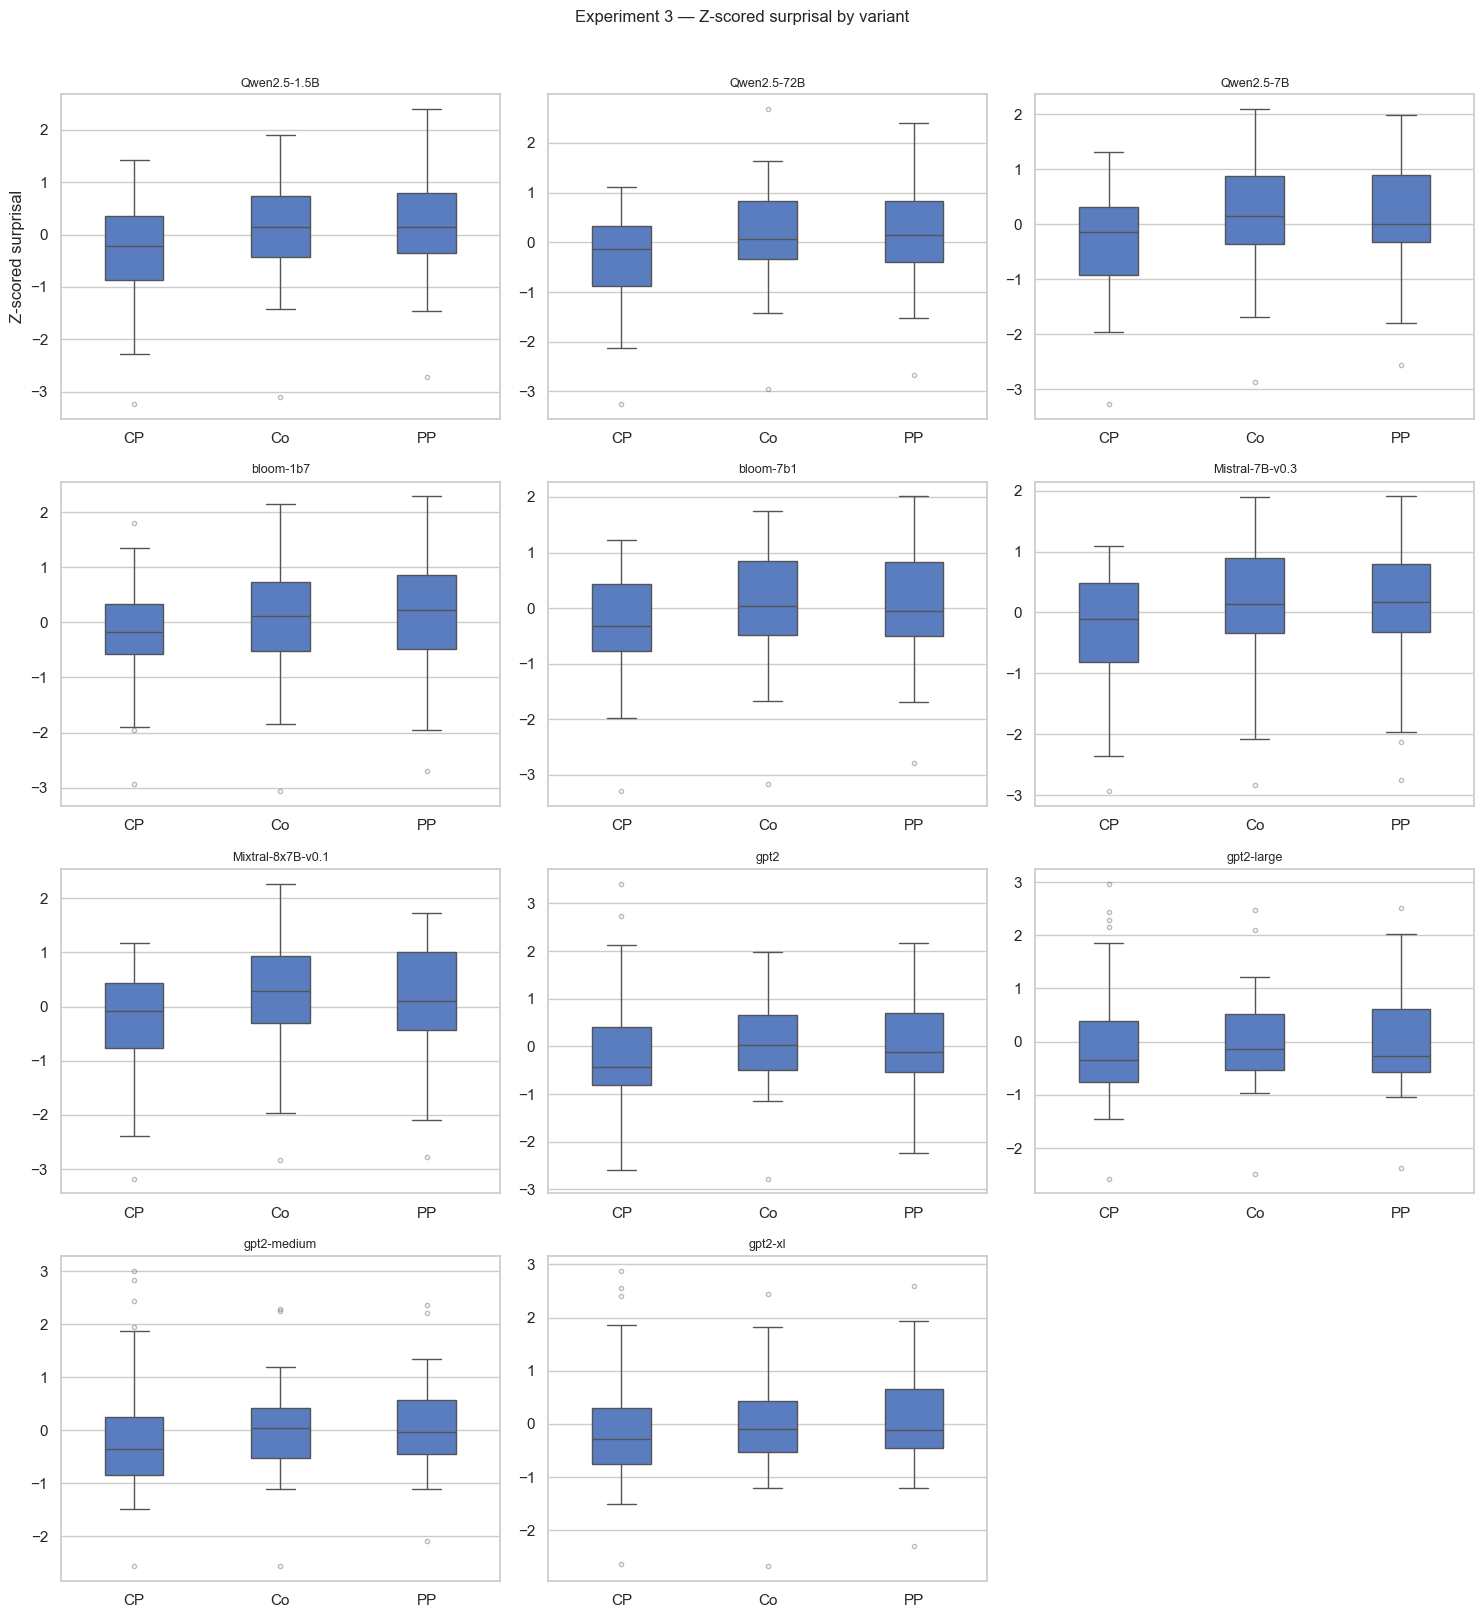

Saved: plots\exp3_surprisal_z_by_variant.png


In [8]:
def plot_surprisal_by_variant(df: pd.DataFrame, exp_num: int,
                               metric: str = "surprisal_z",
                               label: str = "Z-scored surprisal"):
    """Strip + box plot of surprisal per variant, faceted by model."""
    sub = df[df["experiment"] == exp_num].copy()
    models = sorted(sub["model"].unique())
    ncols  = 3
    nrows  = -(-len(models) // ncols)  # ceiling division

    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(5 * ncols, 4 * nrows), sharey=False)
    axes = np.array(axes).flatten()

    for ax, model in zip(axes, models):
        mdf = sub[sub["model"] == model]
        sns.boxplot(data=mdf, x="variant", y=metric, ax=ax,
                    order=sorted(mdf["variant"].unique()),
                    width=0.4, flierprops=dict(marker=".", alpha=0.4))
        ax.set_title(model.split("/")[-1], fontsize=9)
        ax.set_xlabel("")
        ax.set_ylabel(label if ax == axes[0] else "")

    for ax in axes[len(models):]:
        ax.set_visible(False)

    fig.suptitle(f"Experiment {exp_num} — {label} by variant", fontsize=12, y=1.01)
    fig.tight_layout()
    fname = os.path.join(PLOT_DIR, f"exp{exp_num}_{metric}_by_variant.png")
    fig.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {fname}")


for exp in [1, 2, 3]:
    plot_surprisal_by_variant(df, exp, metric="surprisal_z",
                               label="Z-scored surprisal")

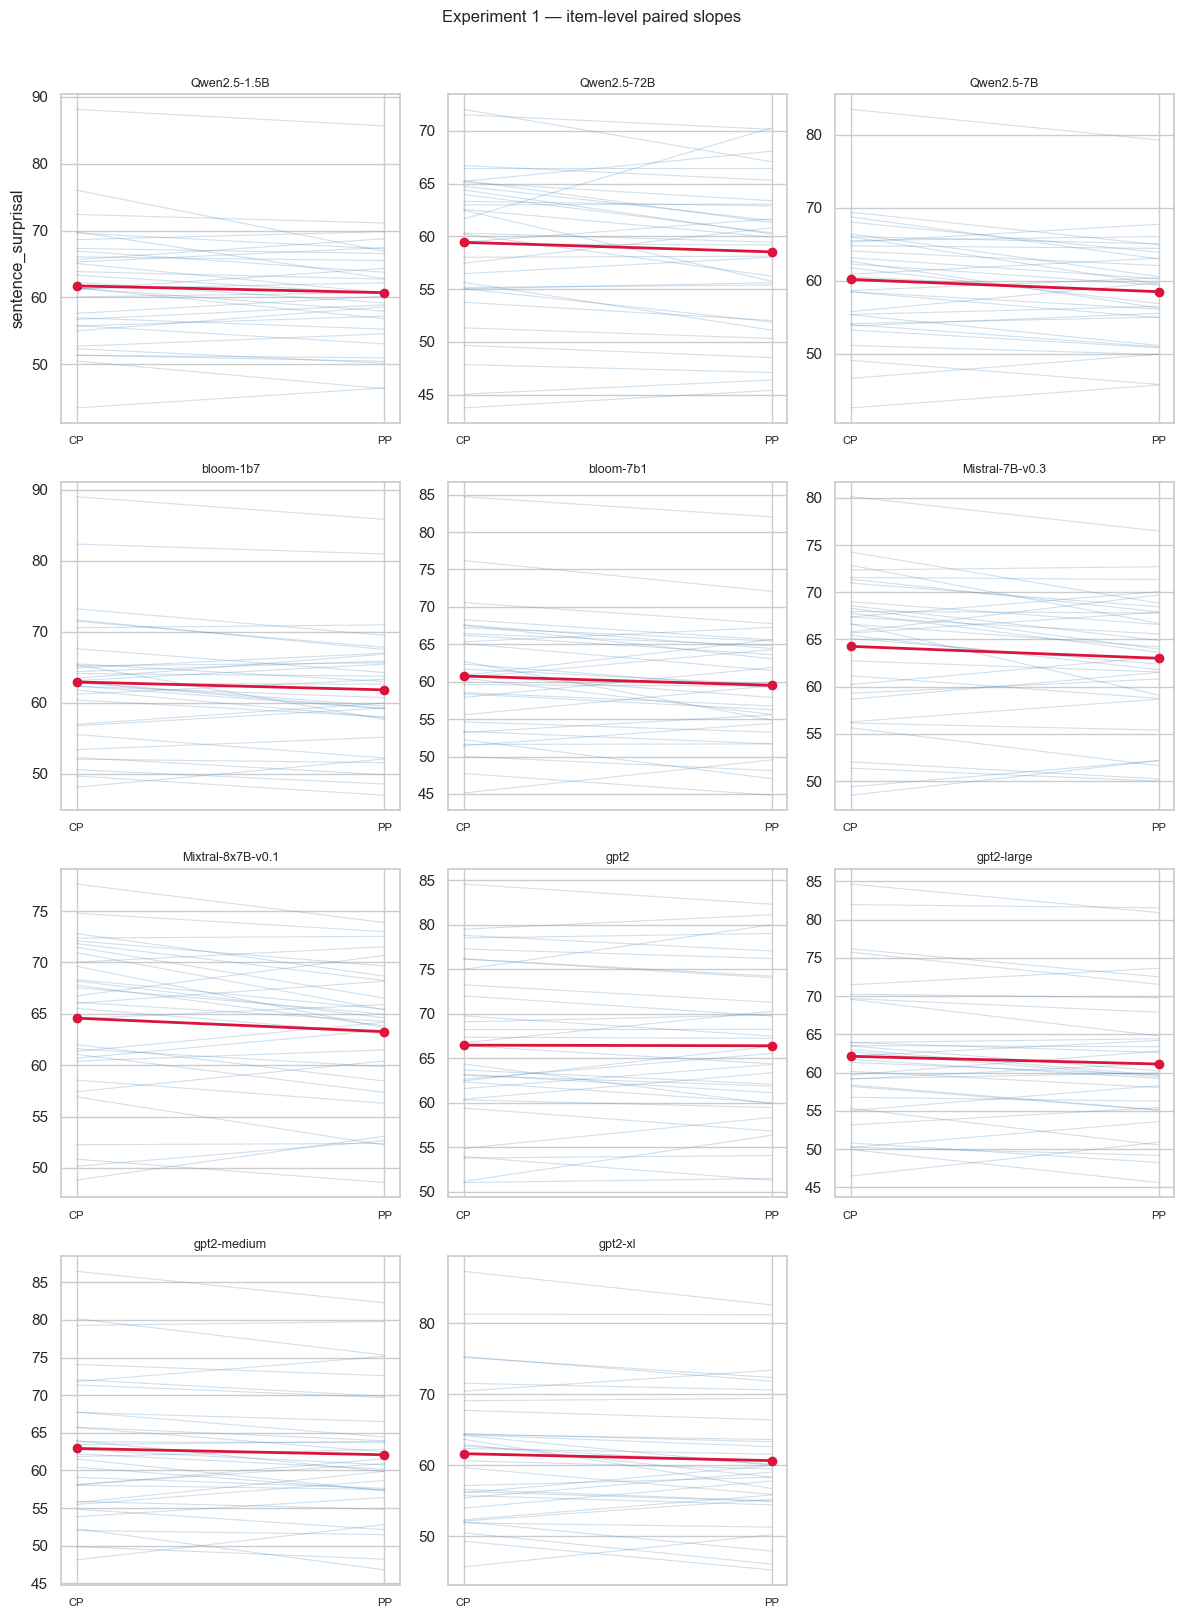

Saved: plots\exp1_paired_slopes.png


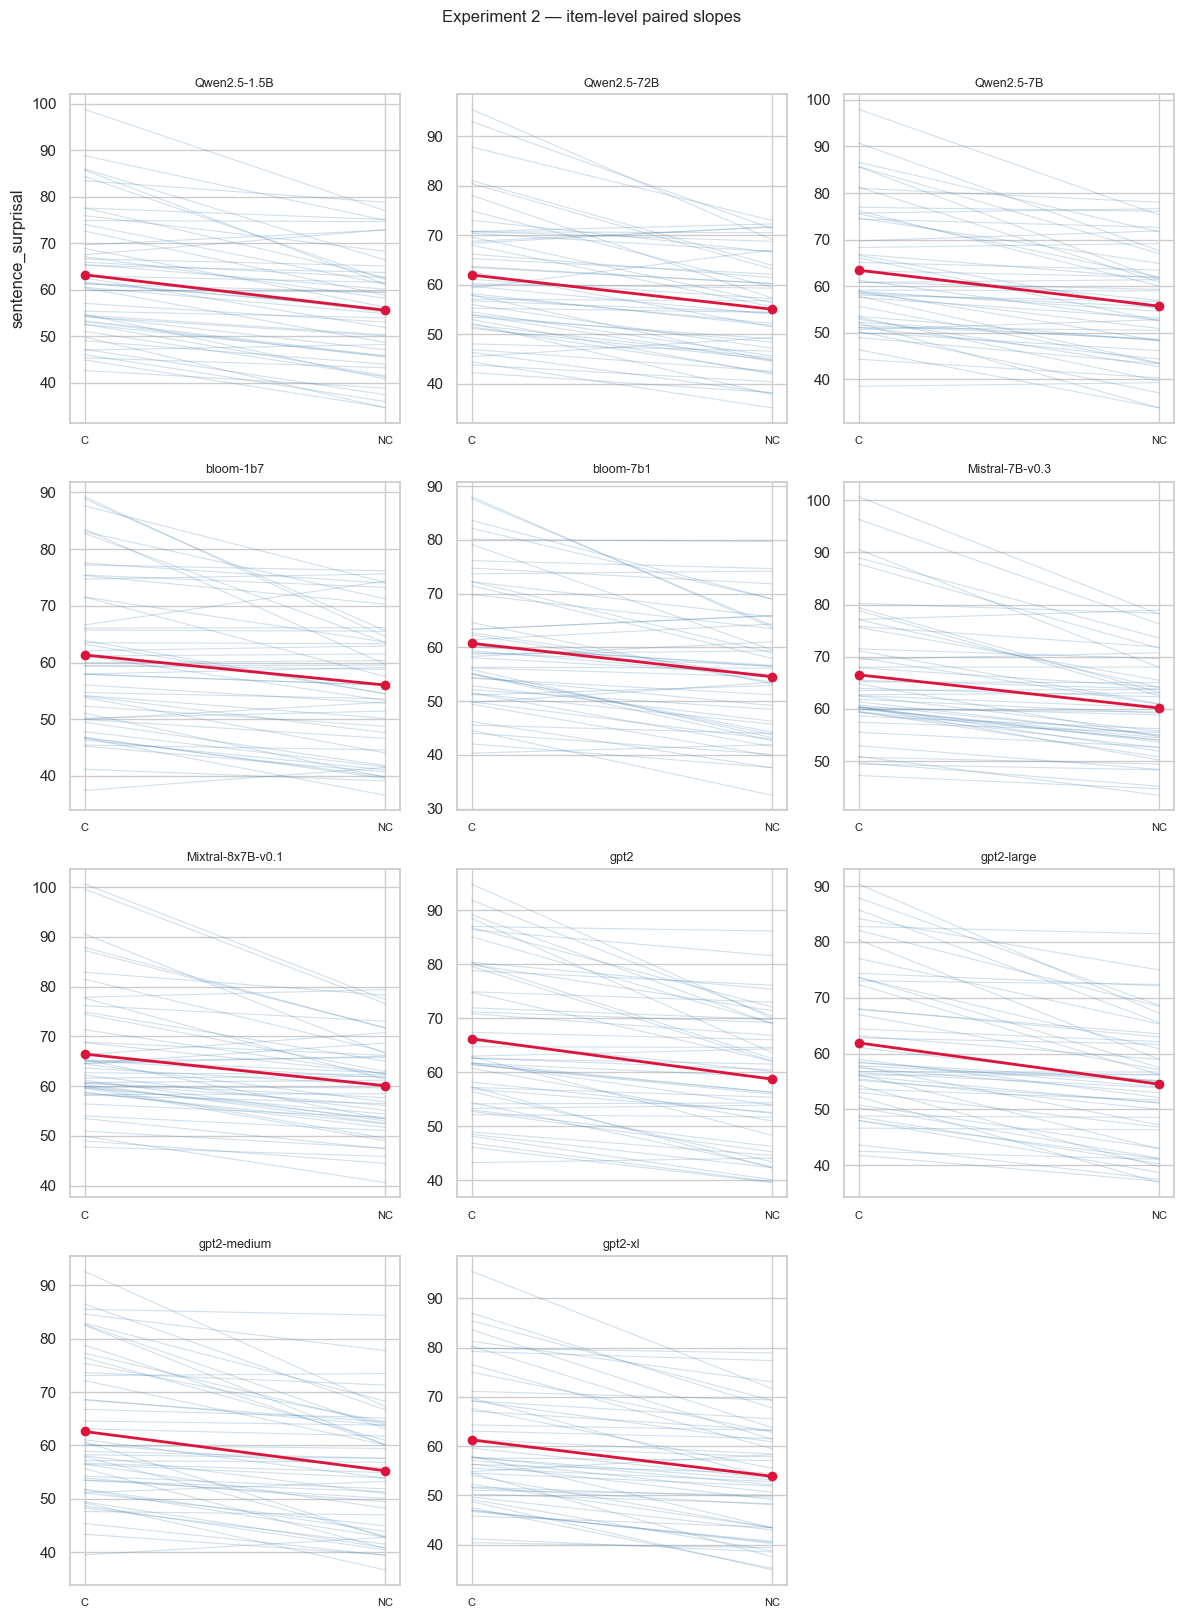

Saved: plots\exp2_paired_slopes.png


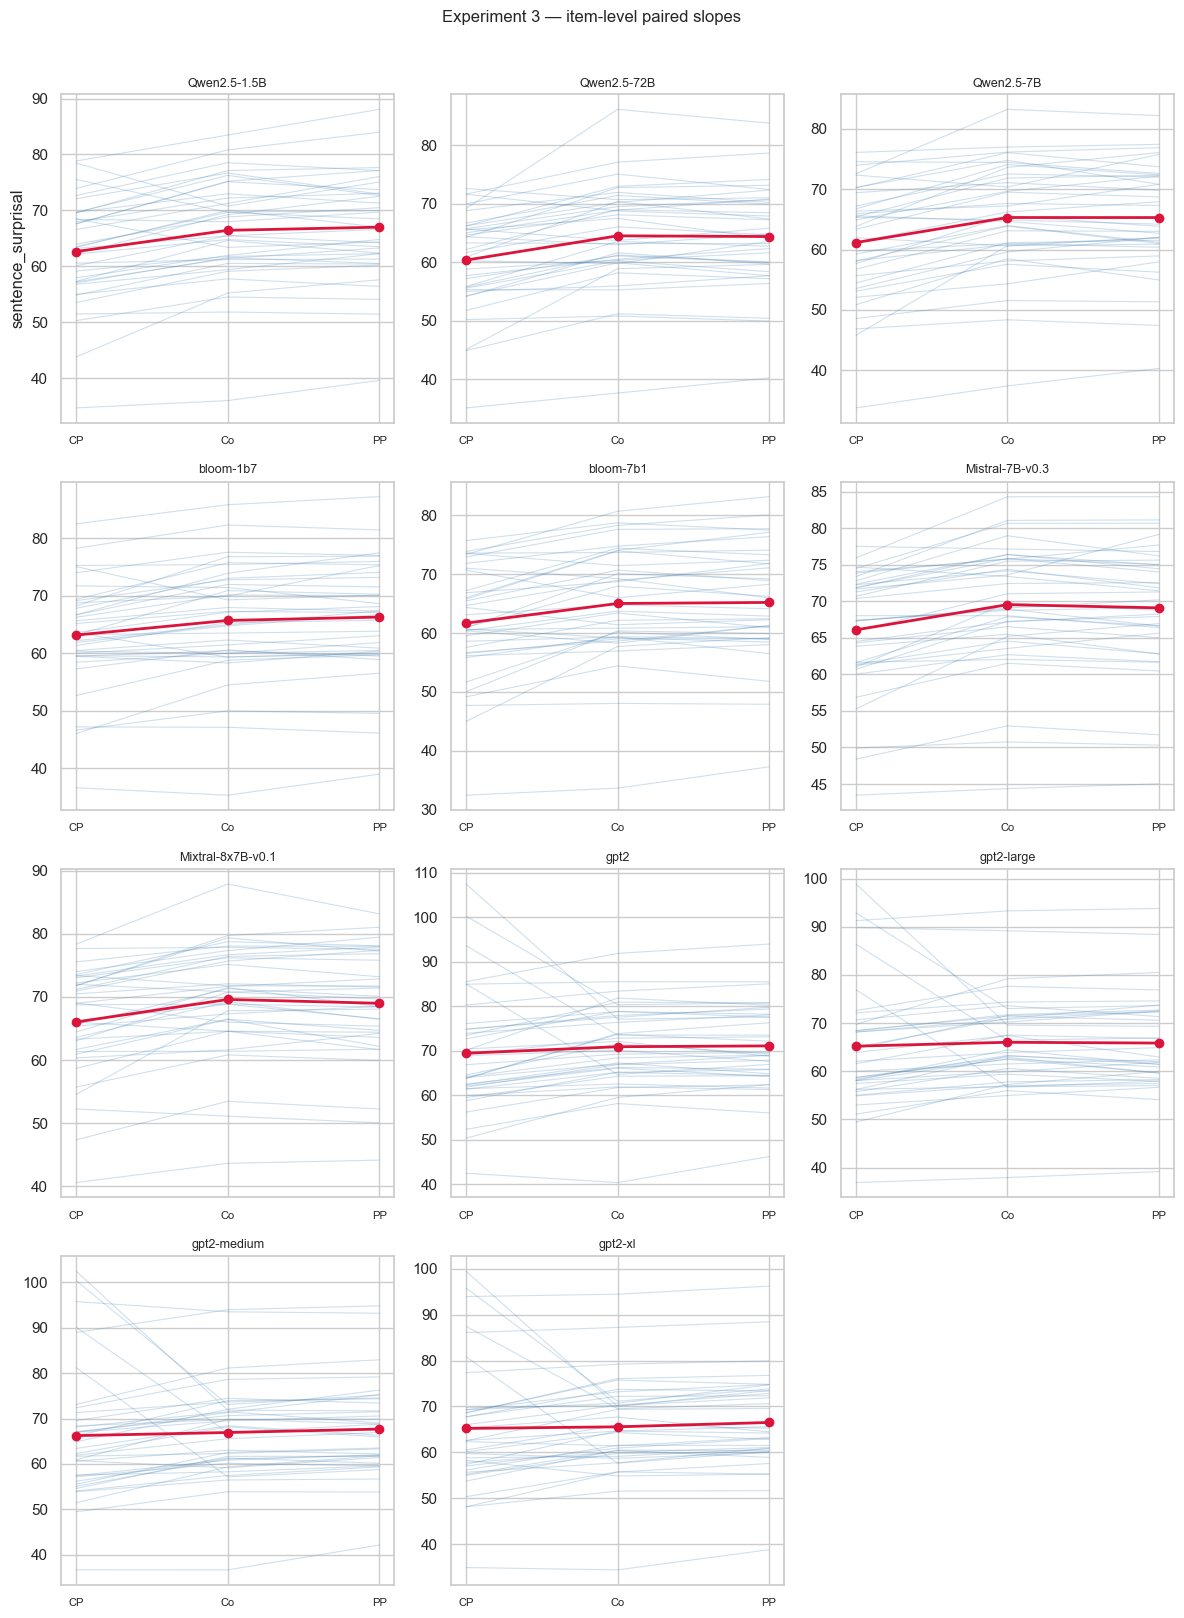

Saved: plots\exp3_paired_slopes.png


In [9]:
def plot_item_paired(df: pd.DataFrame, exp_num: int,
                     metric: str = "sentence_surprisal"):
    """Slope graph: one line per item connecting variant means, faceted by model."""
    sub = df[df["experiment"] == exp_num].copy()
    models  = sorted(sub["model"].unique())
    ncols   = 3
    nrows   = -(-len(models) // ncols)
    variants = sorted(sub["variant"].unique())

    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(4 * ncols, 4 * nrows), sharey=False)
    axes = np.array(axes).flatten()

    for ax, model in zip(axes, models):
        mdf = sub[sub["model"] == model]
        item_means = (
            mdf.groupby(["item_id", "variant"])[metric]
            .mean().reset_index()
            .pivot(index="item_id", columns="variant", values=metric)
            .dropna()
        )
        x = range(len(variants))
        for _, row in item_means.iterrows():
            ax.plot(x, [row[v] for v in variants if v in row.index],
                    color="steelblue", alpha=0.25, linewidth=0.8)
        # overlay means
        means = [item_means[v].mean() for v in variants if v in item_means.columns]
        ax.plot(x[:len(means)], means, color="crimson",
                linewidth=2, marker="o", zorder=5)
        ax.set_xticks(list(x))
        ax.set_xticklabels(variants, fontsize=8)
        ax.set_title(model.split("/")[-1], fontsize=9)
        ax.set_ylabel(metric if ax == axes[0] else "")

    for ax in axes[len(models):]:
        ax.set_visible(False)

    fig.suptitle(f"Experiment {exp_num} — item-level paired slopes",
                 fontsize=12, y=1.01)
    fig.tight_layout()
    fname = os.path.join(PLOT_DIR, f"exp{exp_num}_paired_slopes.png")
    fig.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {fname}")


for exp in [1, 2, 3]:
    plot_item_paired(df, exp)

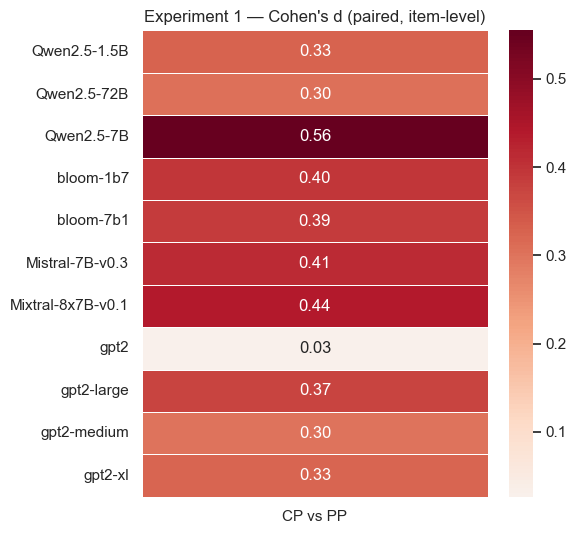

Saved: plots\exp1_cohens_d_heatmap.png


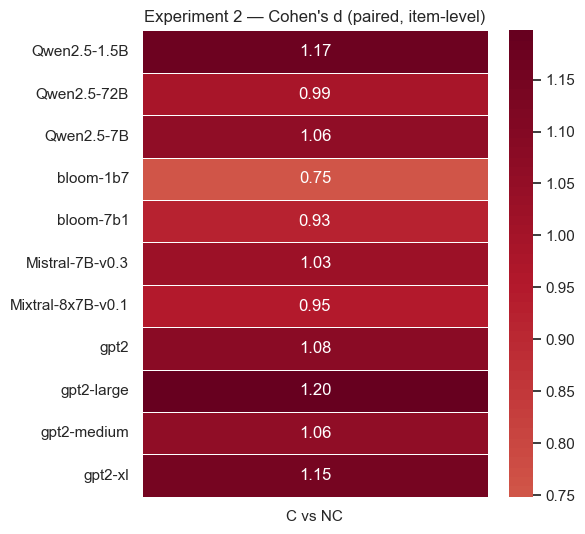

Saved: plots\exp2_cohens_d_heatmap.png


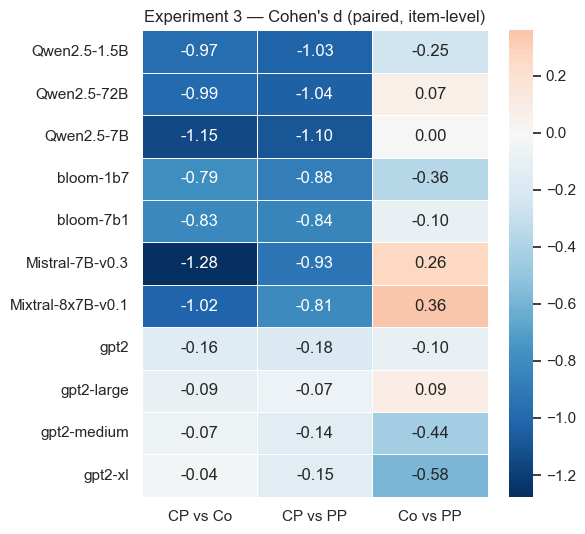

Saved: plots\exp3_cohens_d_heatmap.png


In [10]:
def plot_model_comparison(paired_results: pd.DataFrame, exp_num: int):
    """Heatmap of Cohen's d for each model × variant-pair combination."""
    sub = paired_results[paired_results["experiment"] == exp_num].copy()
    sub["comparison"] = sub["variant_A"] + " vs " + sub["variant_B"]
    pivot = sub.pivot(index="model", columns="comparison", values="cohens_d")
    pivot.index = [m.split("/")[-1] for m in pivot.index]

    fig, ax = plt.subplots(figsize=(max(6, len(pivot.columns) * 2),
                                    max(4, len(pivot) * 0.5)))
    sns.heatmap(pivot, annot=True, fmt=".2f", center=0,
                cmap="RdBu_r", linewidths=0.4, ax=ax)
    ax.set_title(f"Experiment {exp_num} — Cohen's d (paired, item-level)")
    ax.set_xlabel("")
    ax.set_ylabel("")
    fig.tight_layout()
    fname = os.path.join(PLOT_DIR, f"exp{exp_num}_cohens_d_heatmap.png")
    fig.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {fname}")


for exp in [1, 2, 3]:
    plot_model_comparison(paired_results, exp)

## 7. Export summary tables

In [11]:
indep_results.to_csv("results/summary_independent.csv", index=False)
paired_results.to_csv("results/summary_paired.csv",      index=False)
lme_results.to_csv(  "results/summary_lme.csv",          index=False)

print("Saved:")
print("  results/summary_independent.csv")
print("  results/summary_paired.csv")
print("  results/summary_lme.csv")

Saved:
  results/summary_independent.csv
  results/summary_paired.csv
  results/summary_lme.csv


## 8. Paper reproduction (Patejuk & Przepiorkowski 2025)

Each LLM is treated as one complete experiment. The paper's effect of interest is, per-predicate, the
contrast between syntactic frames (PP vs CP in Exp 1; PP&CP vs CP in Exp 2; PP vs PP&CP vs CP in Exp 3).
Three candidate "acceptability" signals are computed from each LLM:

- `acc_mean` = `-mean_surprisal` (per-token average) - what the existing analysis uses
- `acc_sent` = `-sentence_surprisal` (sum across all tokens)
- `acc_crit` = `-(sum of surprisal of K tokens starting at the predicate)` - focuses on the locus of the structural decision

Each metric is z-scored within each LLM (analogous to z-scoring per human respondent in the paper).
Per-predicate LMERs and pairwise contrasts use these z-scores as the dependent variable.

**Note on item pairing.** Exp 1 stimuli have 2 celebrity-paired sentences per (predicate, number, variant)
cell (Latin square). The cell below rebuilds `item_id` to align celebrities across CP/PP variants.


In [12]:
# 8.1 - Acceptability metrics from token surprisals

import json as _json

PRED_FORMS = {
    "ACCOUNT":  ["account", "accounts"],
    "ANNOYED":  ["annoyed"],
    "ASHAMED":  ["ashamed"],
    "DEPEND":   ["depend", "depends"],
    "FAMILIAR": ["familiar"],
    "SPEAK":    ["speak", "speaks", "spoke"],
    "SUFFER":   ["suffer", "suffers"],
    "TALK":     ["talk", "talks", "talked"],
}

# BPE word-boundary markers: \u0120 (byte-BPE / GPT-2 / Llama) and \u2581 (SentencePiece)
_BPE_PREFIXES = ("\u0120", "\u2581")

def _strip_bpe(tok):
    out = tok
    for p in _BPE_PREFIXES:
        out = out.replace(p, "")
    return out.lower()

def critical_region_surprisal(tokens_json, surprisals_json, predicate_lemma, k=4):
    """Sum of token surprisals starting at the predicate, over k tokens.
    Returns NaN if the predicate token can't be located."""
    if pd.isna(tokens_json) or pd.isna(surprisals_json):
        return np.nan
    try:
        toks = _json.loads(tokens_json)
        sups = _json.loads(surprisals_json)
    except Exception:
        return np.nan
    forms = set(PRED_FORMS.get(predicate_lemma, []))
    if not forms:
        return np.nan
    clean = [_strip_bpe(t) for t in toks]
    # Exact match first; fall back to prefix match (handles BPE splits like "ash"+"amed")
    idx = next((i for i, t in enumerate(clean) if t in forms), None)
    if idx is None:
        idx = next((i for i, t in enumerate(clean)
                    if t and any(f.startswith(t) and len(t) >= 3 for f in forms)),
                   None)
    if idx is None:
        return np.nan
    return float(sum(sups[idx:idx + k]))

# Four "acceptability" signals (higher = more acceptable, since acceptability ~ -surprisal)
df["acc_mean"] = -df["mean_surprisal"]
df["acc_sent"] = -df["sentence_surprisal"]
df["acc_crit"] = -df.apply(
    lambda r: critical_region_surprisal(r["tokens"], r["token_surprisals"], r["subkind"], k=4),
    axis=1,
)
# PenLP: log P(s) / ((5 + |s|) / 6)^0.8  — Wu et al. 2016 length penalty (alpha=0.8)
df["acc_pen"] = -df["sentence_surprisal"] / ((5 + df["num_tokens"]) / 6) ** 0.8

# Z-score each metric within each LLM (per-respondent z-scoring, paper-style)
for col in ["acc_mean", "acc_sent", "acc_crit", "acc_pen"]:
    df[f"{col}_z"] = df.groupby("model")[col].transform(z_score_group)

# --- Rebuild item_id with proper exp1 celebrity pairing ---
def _rebuild_item_id(d):
    d = d.copy()
    is_e1 = d["experiment"] == 1
    e1 = (d.loc[is_e1].sort_values(["model", "subkind", "number", "variant", "sentence"])
                       .copy())
    e1["pair_idx"] = e1.groupby(["model", "subkind", "number", "variant"]).cumcount()
    e1["item_id"] = (e1["subkind"].astype(str) + "_"
                     + e1["number"].astype(str) + "_"
                     + e1["pair_idx"].astype(str))
    rest = d.loc[~is_e1].copy()
    rest["item_id"] = rest["subkind"].astype(str) + "_" + rest["number"].astype(str)
    return pd.concat([e1.drop(columns="pair_idx"), rest], ignore_index=True)

df = _rebuild_item_id(df)

# Sanity check: each (model, exp1, item_id) should have one row per variant
e1_check = (df[df.experiment == 1]
            .groupby(["model", "item_id", "variant"]).size().unstack(fill_value=0))
assert (e1_check == 1).all().all(), "Exp 1 item pairing failed."
print("Exp 1 item pairing OK.")
print("Critical-region NaN counts by model (out of total rows for that model):")
display(df.groupby("model")["acc_crit"].apply(lambda s: f"{s.isna().sum()} / {len(s)}"))
df[["model", "experiment", "subkind", "variant", "item_id",
    "acc_mean_z", "acc_sent_z", "acc_crit_z", "acc_pen_z"]].head()


Exp 1 item pairing OK.
Critical-region NaN counts by model (out of total rows for that model):


model
Qwen/Qwen2.5-1.5B               0 / 332
Qwen/Qwen2.5-72B                0 / 332
Qwen/Qwen2.5-7B                 0 / 332
bigscience/bloom-1b7            0 / 332
bigscience/bloom-7b1            0 / 332
mistralai/Mistral-7B-v0.3       0 / 332
mistralai/Mixtral-8x7B-v0.1     0 / 332
openai-community/gpt2           0 / 332
openai-community/gpt2-large     0 / 332
openai-community/gpt2-medium    0 / 332
openai-community/gpt2-xl        0 / 332
Name: acc_crit, dtype: str

,model,experiment,subkind,variant,item_id,acc_mean_z,acc_sent_z,acc_crit_z,acc_pen_z
0,Qwen/Qwen2.5-1.5B,1,ACCOUNT,CP,ACCOUNT_1_0,-0.615500,0.396969,-0.445777,-0.291452
1,Qwen/Qwen2.5-1.5B,1,ACCOUNT,CP,ACCOUNT_1_1,-1.467614,-0.938932,-2.421960,-1.507180
2,Qwen/Qwen2.5-1.5B,1,ACCOUNT,PP,ACCOUNT_1_0,0.803983,0.840203,1.428070,0.896341
3,Qwen/Qwen2.5-1.5B,1,ACCOUNT,PP,ACCOUNT_1_1,-0.050500,-0.591597,1.069713,-0.325471
4,Qwen/Qwen2.5-1.5B,1,ACCOUNT,CP,ACCOUNT_2_0,-1.813293,-1.835178,-1.367055,-2.154750


### 8.2 Reference values from the paper

Estimated mean differences (EMDs) and Tukey HSD p-values reported in the paper, in absolute
thermometer units. Sign convention here: `EMD(A_vs_B) = mean(A) - mean(B)`, matching the paper's
footnotes 33, 34, 38, and 48.


In [13]:
# 8.2 - Paper EMDs (predicate x contrast). Sign is mean(A) - mean(B) for the contrast key A_vs_B.
PAPER_EMD = {
    1: {  # Exp 1: CP - PP, footnotes 33-34
        "ANNOYED":  {"CP_vs_PP":  0.33, "p": 0.577},
        "ASHAMED":  {"CP_vs_PP": -0.27, "p": 0.643},
        "FAMILIAR": {"CP_vs_PP": -5.58, "p": 0.001},
        "ACCOUNT":  {"CP_vs_PP": -6.64, "p": 0.001},
        "DEPEND":   {"CP_vs_PP": -8.44, "p": 0.001},
        "SPEAK":    {"CP_vs_PP":-10.74, "p": 0.001},
        "SUFFER":   {"CP_vs_PP": -8.26, "p": 0.001},
        "TALK":     {"CP_vs_PP":-10.04, "p": 0.001},
    },
    2: {  # Exp 2: PP&CP - CP (paper variant codes: NC = PP&CP, C = CP), footnote 38
        "ACCOUNT":  {"PPCP_vs_CP":  1.07, "p": 0.135},
        "FAMILIAR": {"PPCP_vs_CP":  2.59, "p": 0.001},
        "DEPEND":   {"PPCP_vs_CP":  4.29, "p": 0.001},
        "SPEAK":    {"PPCP_vs_CP":  3.77, "p": 0.001},
        "TALK":     {"PPCP_vs_CP":  6.85, "p": 0.001},
        "SUFFER":   {"PPCP_vs_CP":  4.30, "p": 0.001},
    },
    3: {  # Exp 3 (variant codes: PP, Co = PP&CP, CP), footnote 48
        "FAMILIAR": {"PP_vs_PPCP": 0.44, "PPCP_vs_CP": 2.26, "PP_vs_CP": 2.70},
        "DEPEND":   {"PP_vs_PPCP": 2.73, "PPCP_vs_CP": 4.32, "PP_vs_CP": 7.05},
        "SPEAK":    {"PP_vs_PPCP": 2.78, "PPCP_vs_CP": 4.08, "PP_vs_CP": 6.86},
        "TALK":     {"PP_vs_PPCP": 1.63, "PPCP_vs_CP": 7.33, "PP_vs_CP": 8.97},
    },
}

# Mapping from paper labels to dataframe variant codes
PAPER_TO_DATA = {
    1: {"PP": "PP", "CP": "CP"},
    2: {"PPCP": "NC", "CP": "C"},
    3: {"PP": "PP", "PPCP": "Co", "CP": "CP"},
}


### 8.3 Per-predicate LME + pairwise contrasts

For each (LLM, experiment, predicate), fit `metric_z ~ C(variant) + (1 | item_id)` and compute paired
t-tests on item-level differences (the LMER-equivalent contrast when items are matched). Run for all
three metrics so we can later pick the one that best tracks human results.


In [14]:
# 8.3 - Per-predicate LME + pairwise contrasts

from itertools import combinations as _comb
import statsmodels.formula.api as _smf

def per_predicate_contrasts(df, metric_z):
    rows = []
    for (model, exp, pred), gdf in df.groupby(["model", "experiment", "subkind"]):
        gdf = gdf[["item_id", "variant", metric_z]].dropna()
        variants = sorted(gdf["variant"].unique())
        if len(variants) < 2:
            continue
        # LMER for the variant main effect (record convergence + min Wald p for non-intercept terms)
        lme_p, converged = np.nan, False
        try:
            lme = _smf.mixedlm(f"{metric_z} ~ C(variant)", gdf,
                               groups=gdf["item_id"]).fit(reml=False, method="lbfgs")
            converged = bool(lme.converged)
            non_int = [t for t in lme.pvalues.index if t != "Intercept"]
            if non_int:
                lme_p = float(min(lme.pvalues[non_int]))
        except Exception:
            pass
        wide = (gdf.pivot_table(index="item_id", columns="variant",
                                 values=metric_z, aggfunc="mean"))
        for v1, v2 in _comb(variants, 2):
            paired = wide[[v1, v2]].dropna()
            if len(paired) < 3:
                continue
            t, p = stats.ttest_rel(paired[v1], paired[v2])
            rows.append({
                "model": model, "experiment": exp, "predicate": pred,
                "v1": v1, "v2": v2,
                "mean_v1": paired[v1].mean(), "mean_v2": paired[v2].mean(),
                "EMD_z": paired[v1].mean() - paired[v2].mean(),
                "t": float(t), "p_paired": float(p),
                "n_items": len(paired),
                "lme_min_p": lme_p, "lme_converged": converged,
            })
    return pd.DataFrame(rows)

paper_per_pred = {
    metric: per_predicate_contrasts(df, f"{metric}_z")
    for metric in ["acc_mean", "acc_sent", "acc_crit", "acc_pen"]
}

print("Rows per metric:")
for m, t in paper_per_pred.items():
    print(f"  {m:10s} -> {len(t)} rows, {t['model'].nunique()} models, "
          f"{t['predicate'].nunique()} predicates")
paper_per_pred["acc_mean"].head(8).round(3)


C:\Users\Devin\Documents\ABE LLM LAB\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)


C:\Users\Devin\Documents\ABE LLM LAB\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
C:\Users\Devin\Documents\ABE LLM LAB\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2054: UserWarning: The random effects covariance matrix is singular.
  warnings.warn(_warn_cov_sing)
C:\Users\Devin\Documents\ABE LLM LAB\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
C:\Users\Devin\Documents\ABE LLM LAB\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2245: UserWarning: The random effects covariance matrix is singular.
  warnings.warn(_warn_cov_sing)


C:\Users\Devin\Documents\ABE LLM LAB\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
C:\Users\Devin\Documents\ABE LLM LAB\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2054: UserWarning: The random effects covariance matrix is singular.
  warnings.warn(_warn_cov_sing)
C:\Users\Devin\Documents\ABE LLM LAB\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
C:\Users\Devin\Documents\ABE LLM LAB\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2245: UserWarning: The random effects covariance matrix is singular.
  warnings.warn(_warn_cov_sing)
C:\Users\Devin\Documents\ABE LLM LAB\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.

C:\Users\Devin\Documents\ABE LLM LAB\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
C:\Users\Devin\Documents\ABE LLM LAB\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2054: UserWarning: The random effects covariance matrix is singular.
  warnings.warn(_warn_cov_sing)
C:\Users\Devin\Documents\ABE LLM LAB\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
C:\Users\Devin\Documents\ABE LLM LAB\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2245: UserWarning: The random effects covariance matrix is singular.
  warnings.warn(_warn_cov_sing)
C:\Users\Devin\Documents\ABE LLM LAB\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.

C:\Users\Devin\Documents\ABE LLM LAB\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
C:\Users\Devin\Documents\ABE LLM LAB\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2054: UserWarning: The random effects covariance matrix is singular.
  warnings.warn(_warn_cov_sing)
C:\Users\Devin\Documents\ABE LLM LAB\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
C:\Users\Devin\Documents\ABE LLM LAB\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2245: UserWarning: The random effects covariance matrix is singular.
  warnings.warn(_warn_cov_sing)
C:\Users\Devin\Documents\ABE LLM LAB\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.

...

C:\Users\Devin\Documents\ABE LLM LAB\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
C:\Users\Devin\Documents\ABE LLM LAB\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2054: UserWarning: The random effects covariance matrix is singular.
  warnings.warn(_warn_cov_sing)
C:\Users\Devin\Documents\ABE LLM LAB\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
C:\Users\Devin\Documents\ABE LLM LAB\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2245: UserWarning: The random effects covariance matrix is singular.
  warnings.warn(_warn_cov_sing)
C:\Users\Devin\Documents\ABE LLM LAB\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.

C:\Users\Devin\Documents\ABE LLM LAB\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
C:\Users\Devin\Documents\ABE LLM LAB\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2054: UserWarning: The random effects covariance matrix is singular.
  warnings.warn(_warn_cov_sing)
C:\Users\Devin\Documents\ABE LLM LAB\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
C:\Users\Devin\Documents\ABE LLM LAB\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2245: UserWarning: The random effects covariance matrix is singular.
  warnings.warn(_warn_cov_sing)
C:\Users\Devin\Documents\ABE LLM LAB\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.

C:\Users\Devin\Documents\ABE LLM LAB\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
C:\Users\Devin\Documents\ABE LLM LAB\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2054: UserWarning: The random effects covariance matrix is singular.
  warnings.warn(_warn_cov_sing)
C:\Users\Devin\Documents\ABE LLM LAB\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
C:\Users\Devin\Documents\ABE LLM LAB\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2245: UserWarning: The random effects covariance matrix is singular.
  warnings.warn(_warn_cov_sing)


Rows per metric:
  acc_mean   -> 286 rows, 11 models, 8 predicates
  acc_sent   -> 286 rows, 11 models, 8 predicates
  acc_crit   -> 286 rows, 11 models, 8 predicates
  acc_pen    -> 286 rows, 11 models, 8 predicates


,model,experiment,predicate,v1,v2,mean_v1,mean_v2,EMD_z,t,p_paired,n_items,lme_min_p,lme_converged
0,Qwen/Qwen2.5-1.5B,1,ACCOUNT,CP,PP,-1.238,0.179,-1.417,-9.274,0.000,8,0.0,True
1,Qwen/Qwen2.5-1.5B,1,ANNOYED,CP,PP,0.550,1.077,-0.527,-12.962,0.000,8,0.0,True
2,Qwen/Qwen2.5-1.5B,1,ASHAMED,CP,PP,0.074,0.774,-0.701,-17.693,0.000,8,0.0,True
3,Qwen/Qwen2.5-1.5B,1,DEPEND,CP,PP,-1.079,0.322,-1.402,-16.038,0.000,8,0.0,True
4,Qwen/Qwen2.5-1.5B,1,FAMILIAR,CP,PP,-0.773,0.414,-1.188,-5.771,0.001,8,0.0,True
5,Qwen/Qwen2.5-1.5B,1,SPEAK,CP,PP,-0.766,0.153,-0.918,-10.002,0.000,8,0.0,True
6,Qwen/Qwen2.5-1.5B,1,SUFFER,CP,PP,-0.605,0.504,-1.109,-10.085,0.000,8,0.0,True
7,Qwen/Qwen2.5-1.5B,1,TALK,CP,PP,-0.888,0.442,-1.330,-15.745,0.000,8,0.0,True


### 8.4 Figure 3 / 4 / 7-style plots

For each metric, produce one figure per experiment with one panel per LLM, showing z-scored mean
acceptability (with 95% CI bars) by predicate x variant. Predicate ordering matches the paper.


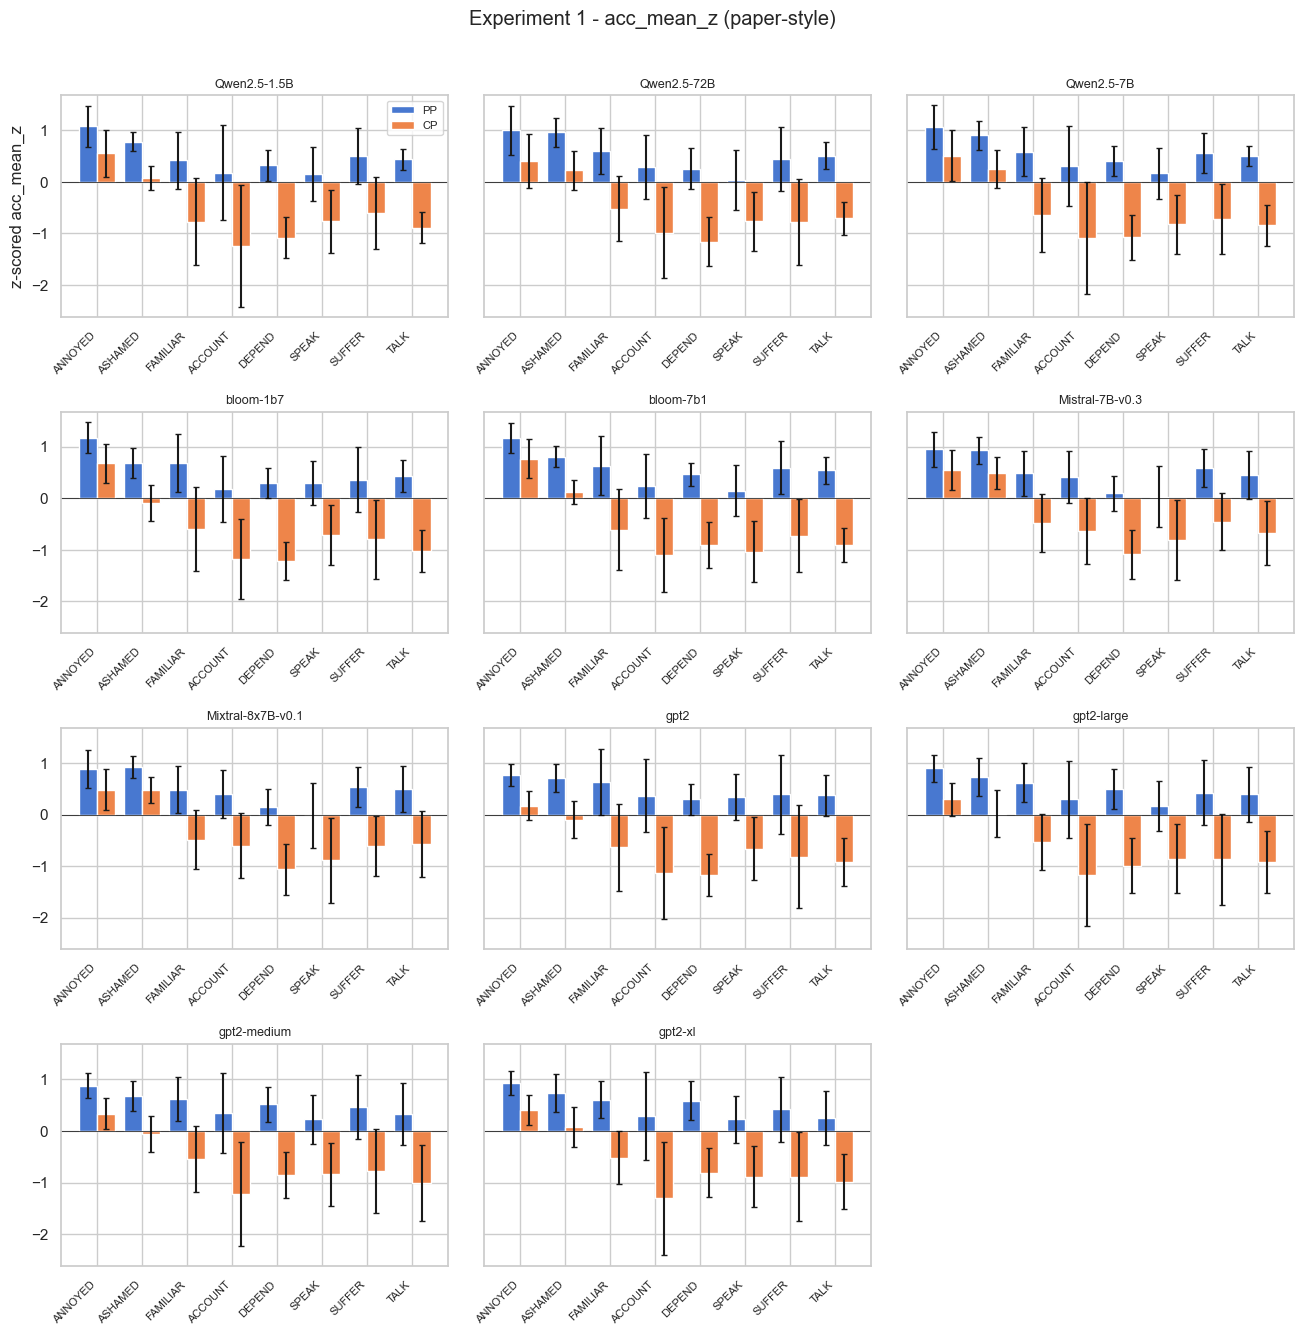

Saved: plots\paper_exp1_acc_mean_z.png


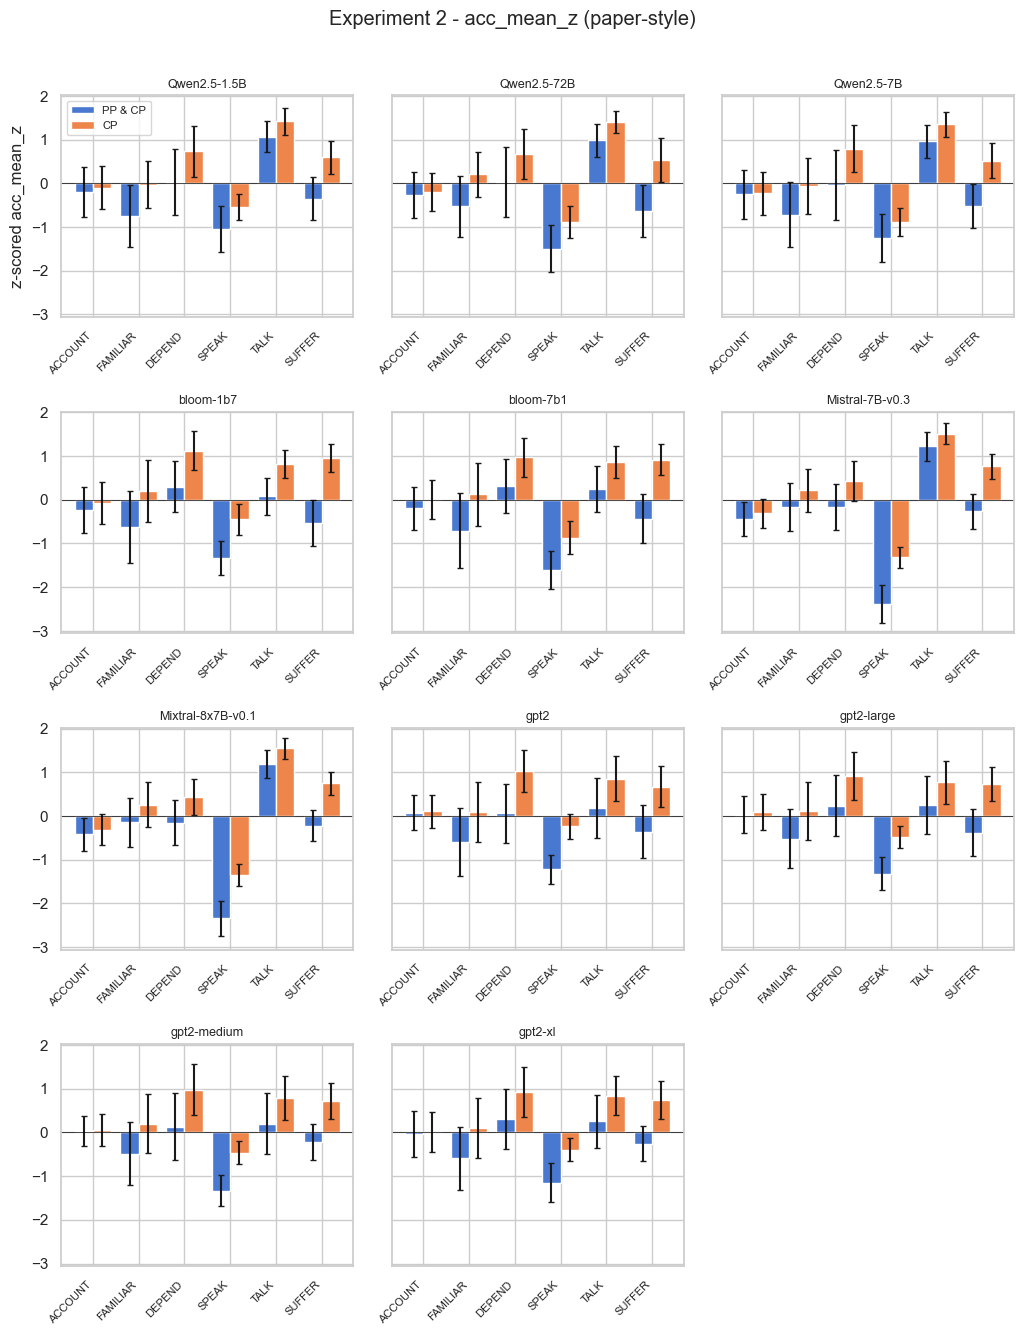

Saved: plots\paper_exp2_acc_mean_z.png


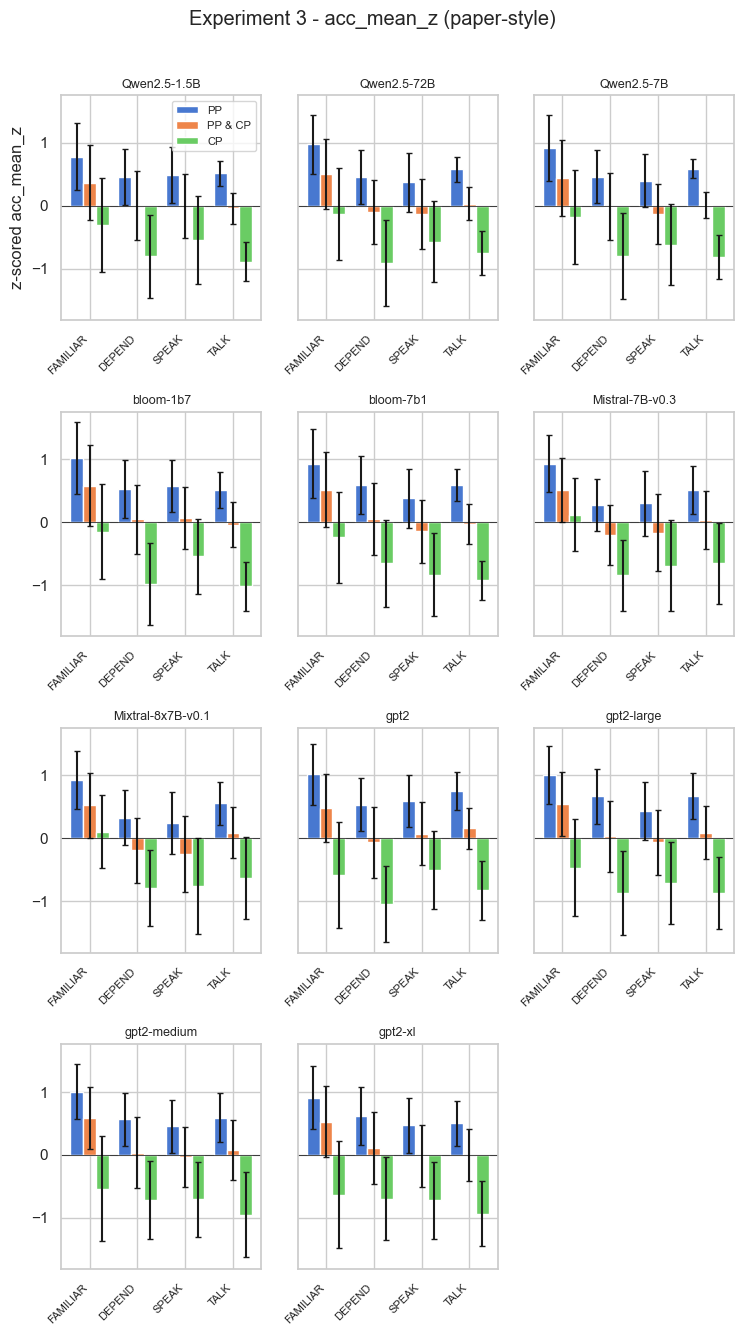

Saved: plots\paper_exp3_acc_mean_z.png


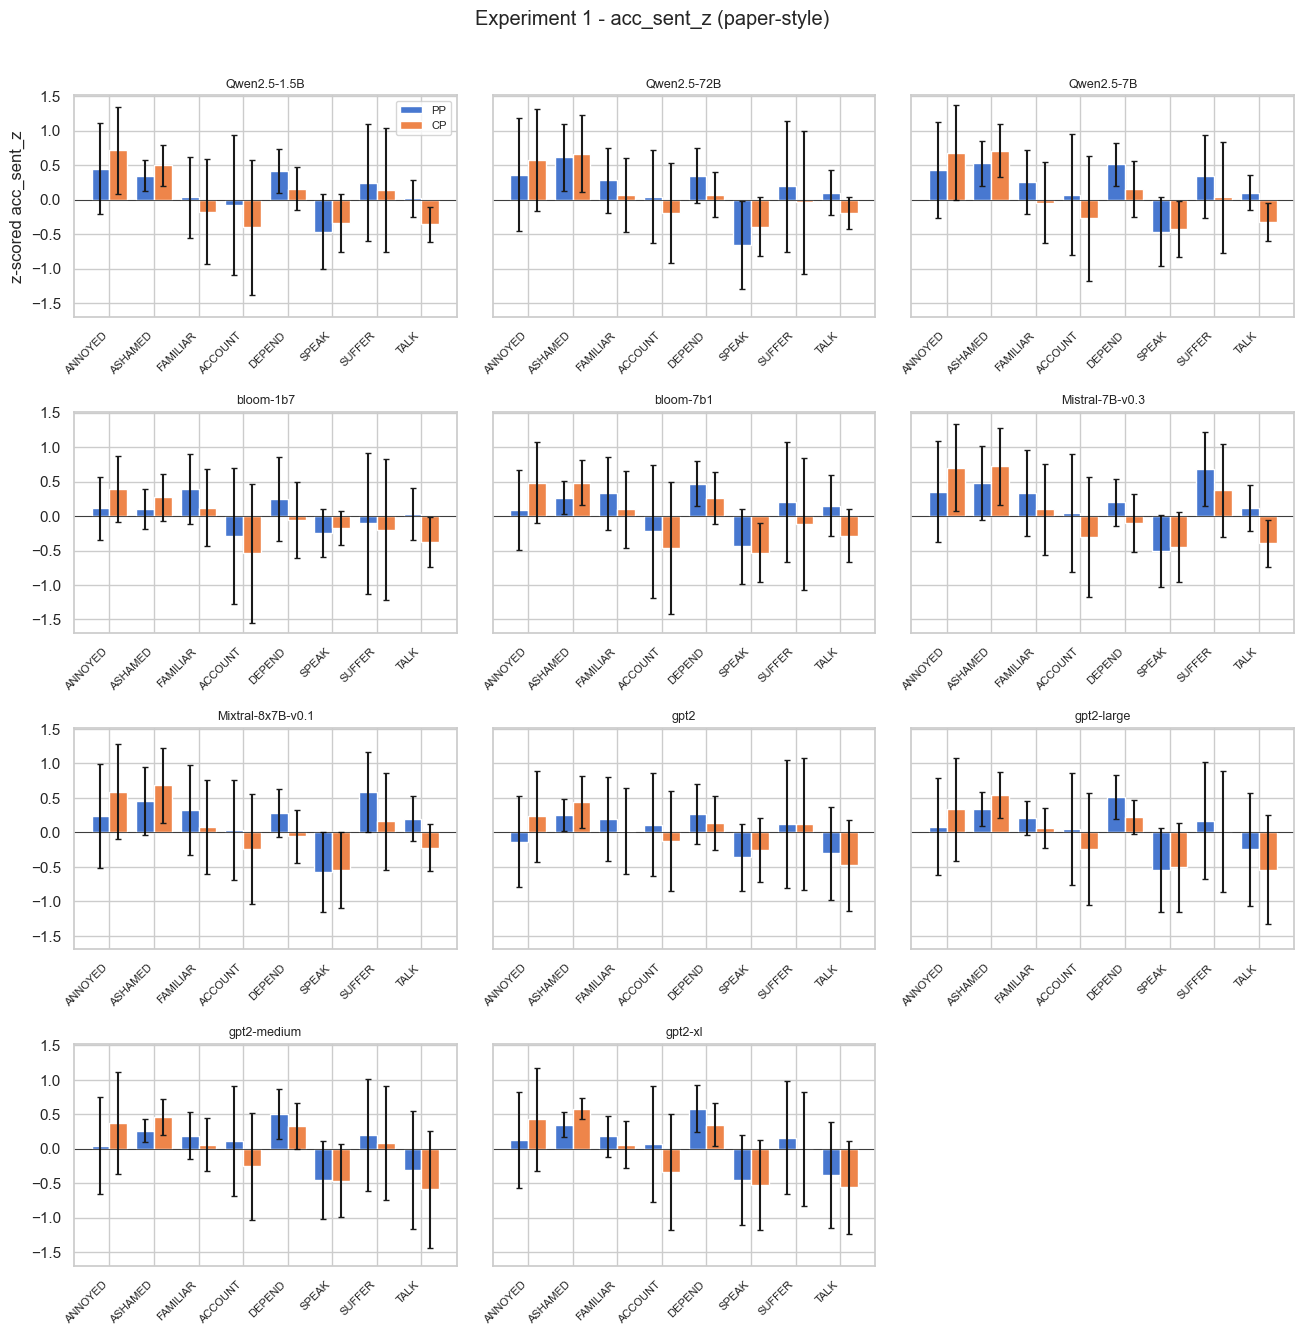

Saved: plots\paper_exp1_acc_sent_z.png


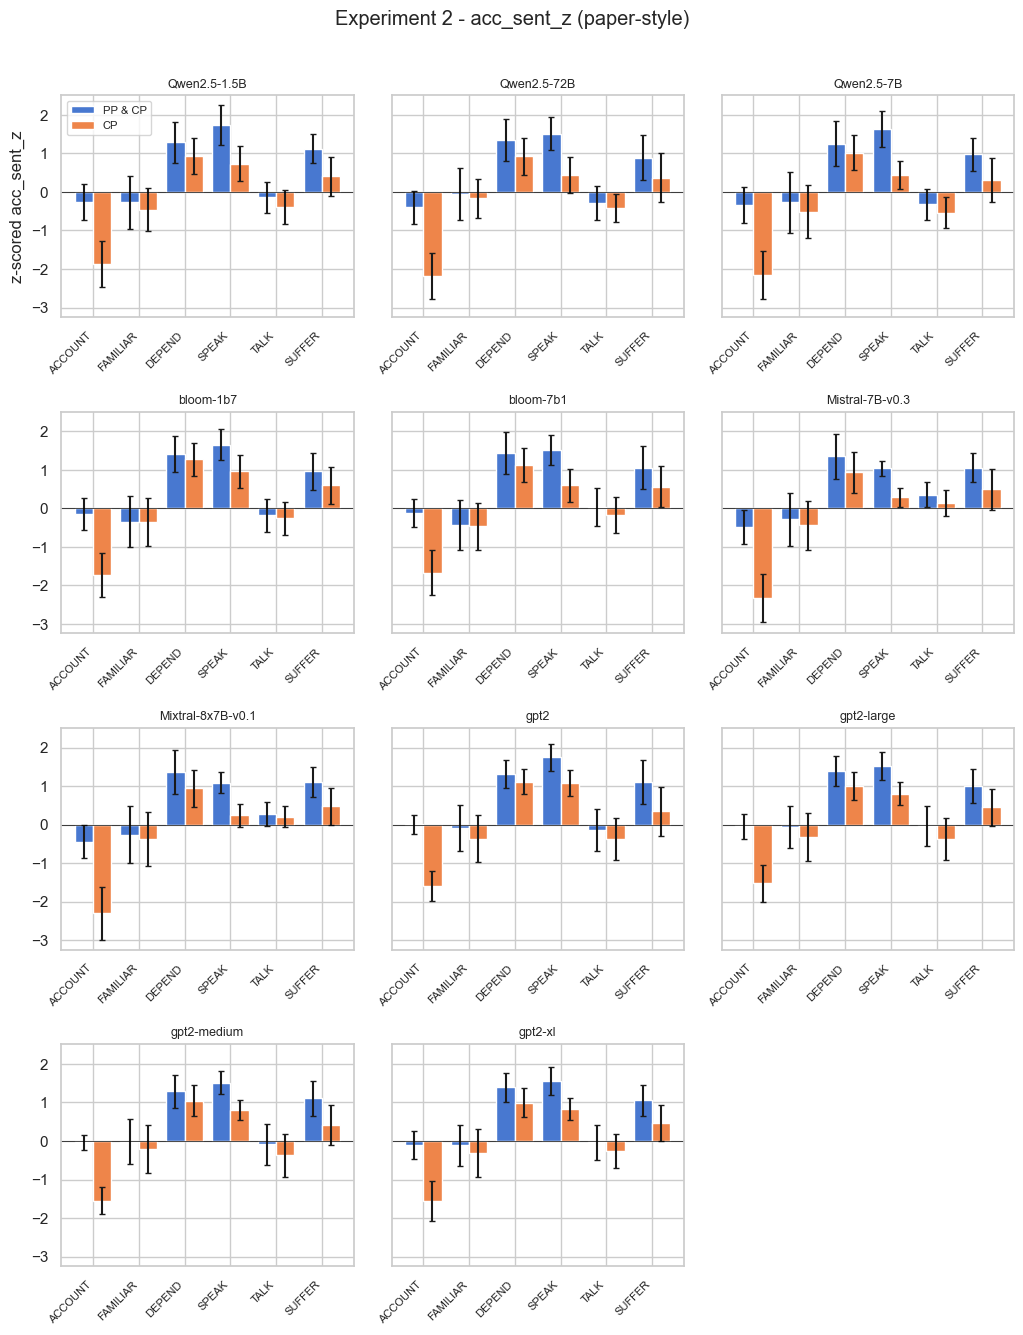

Saved: plots\paper_exp2_acc_sent_z.png


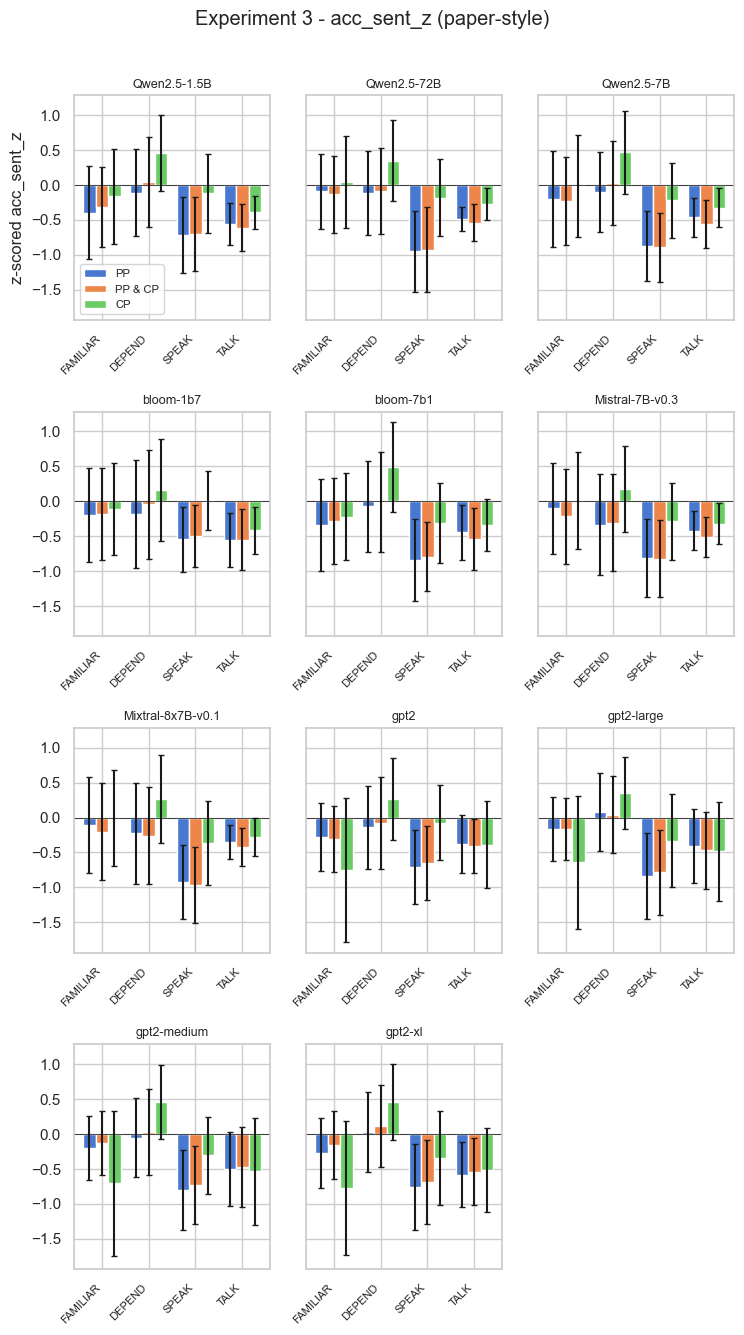

Saved: plots\paper_exp3_acc_sent_z.png


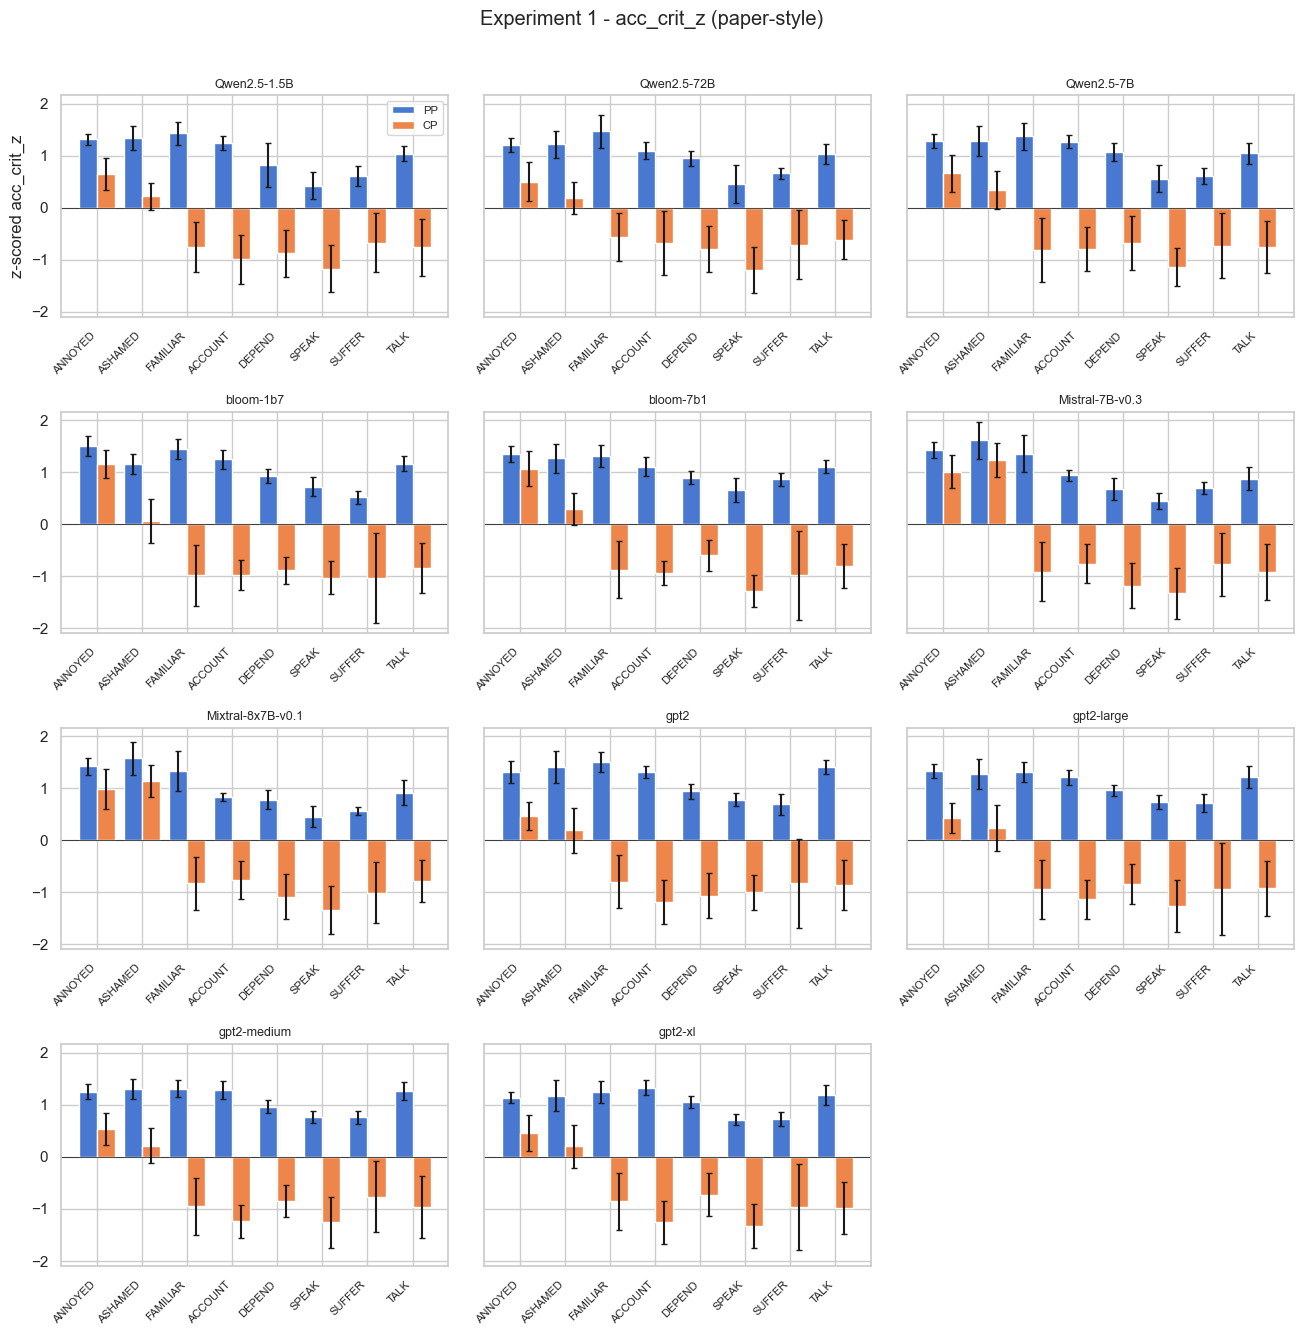

Saved: plots\paper_exp1_acc_crit_z.png


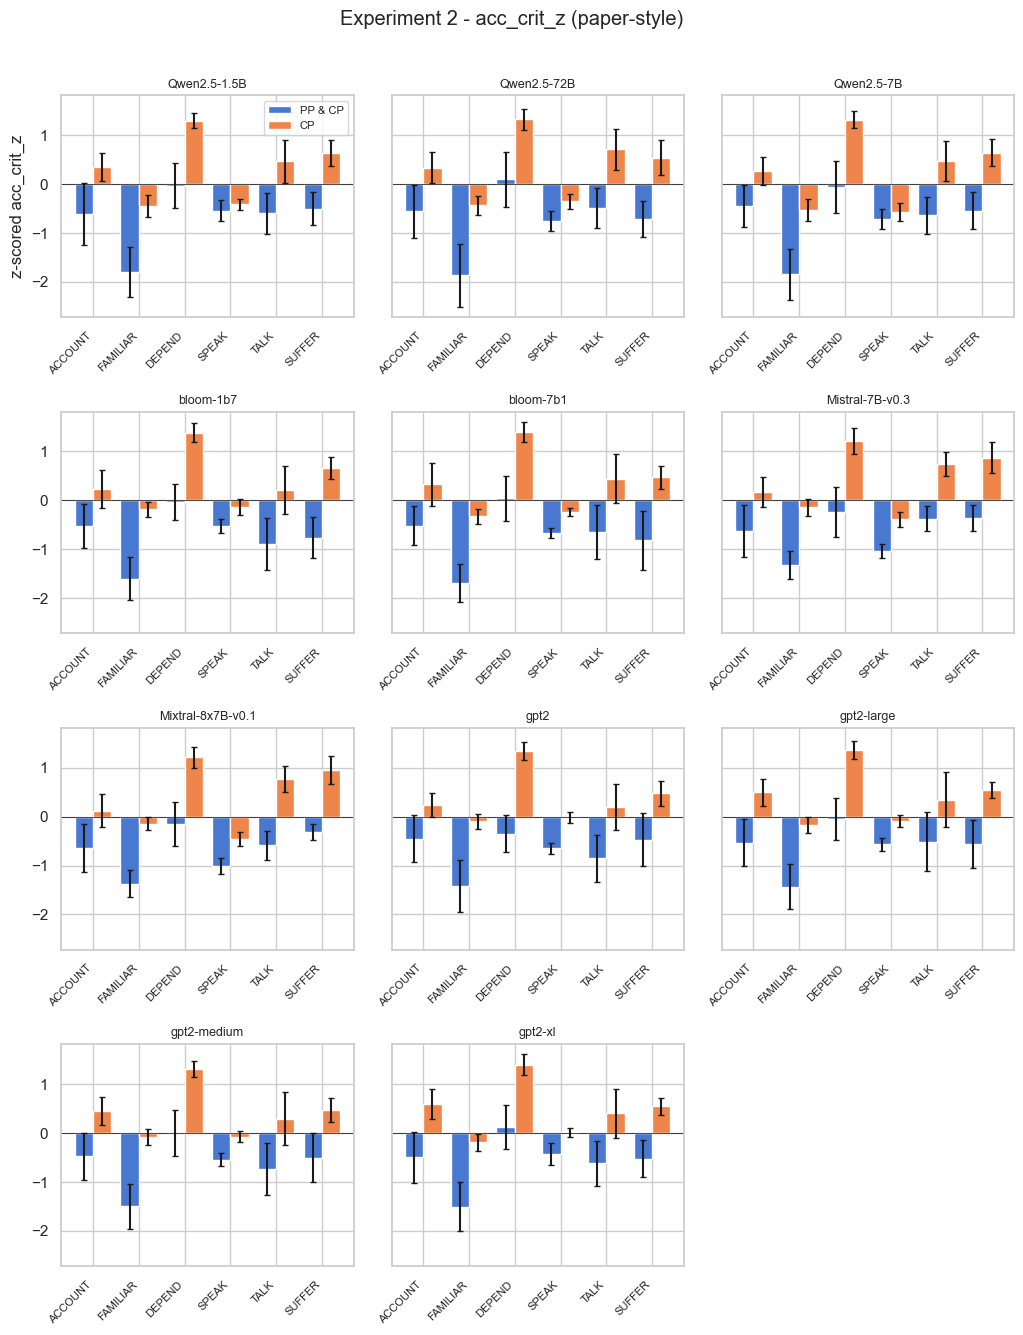

Saved: plots\paper_exp2_acc_crit_z.png


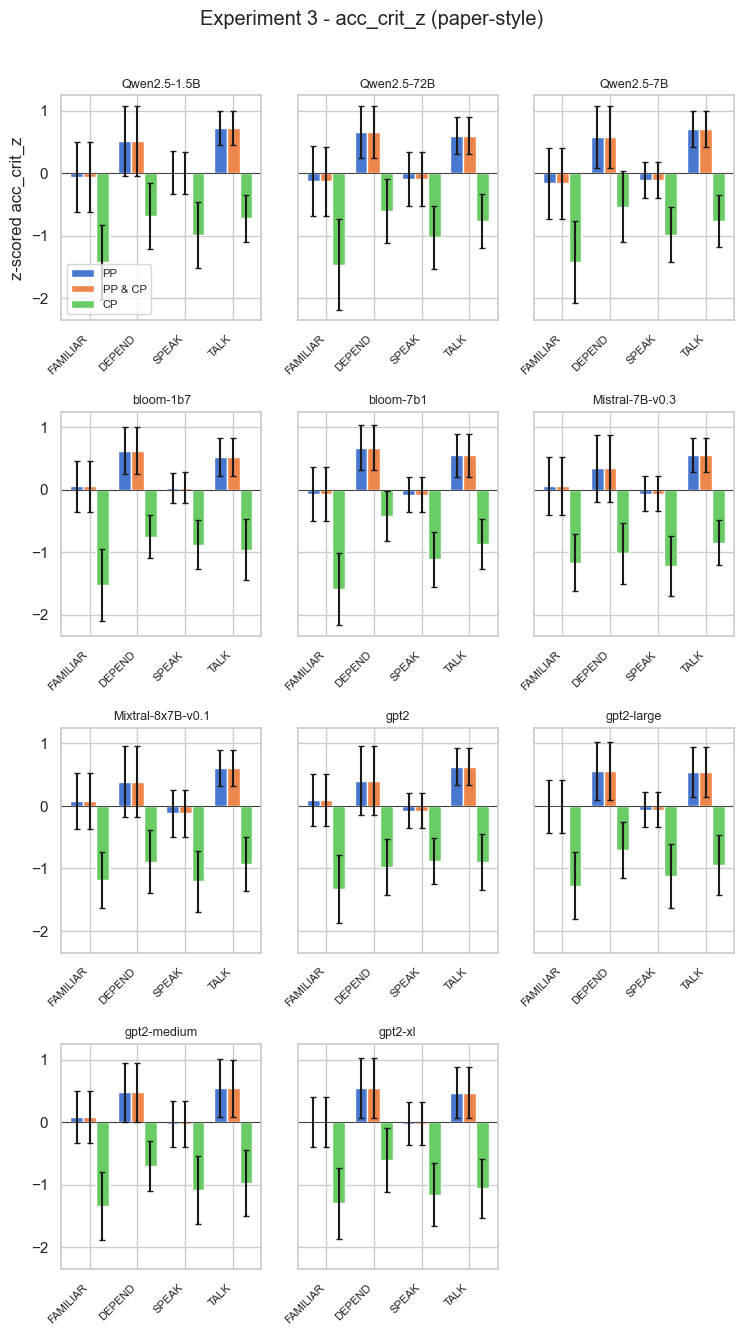

Saved: plots\paper_exp3_acc_crit_z.png


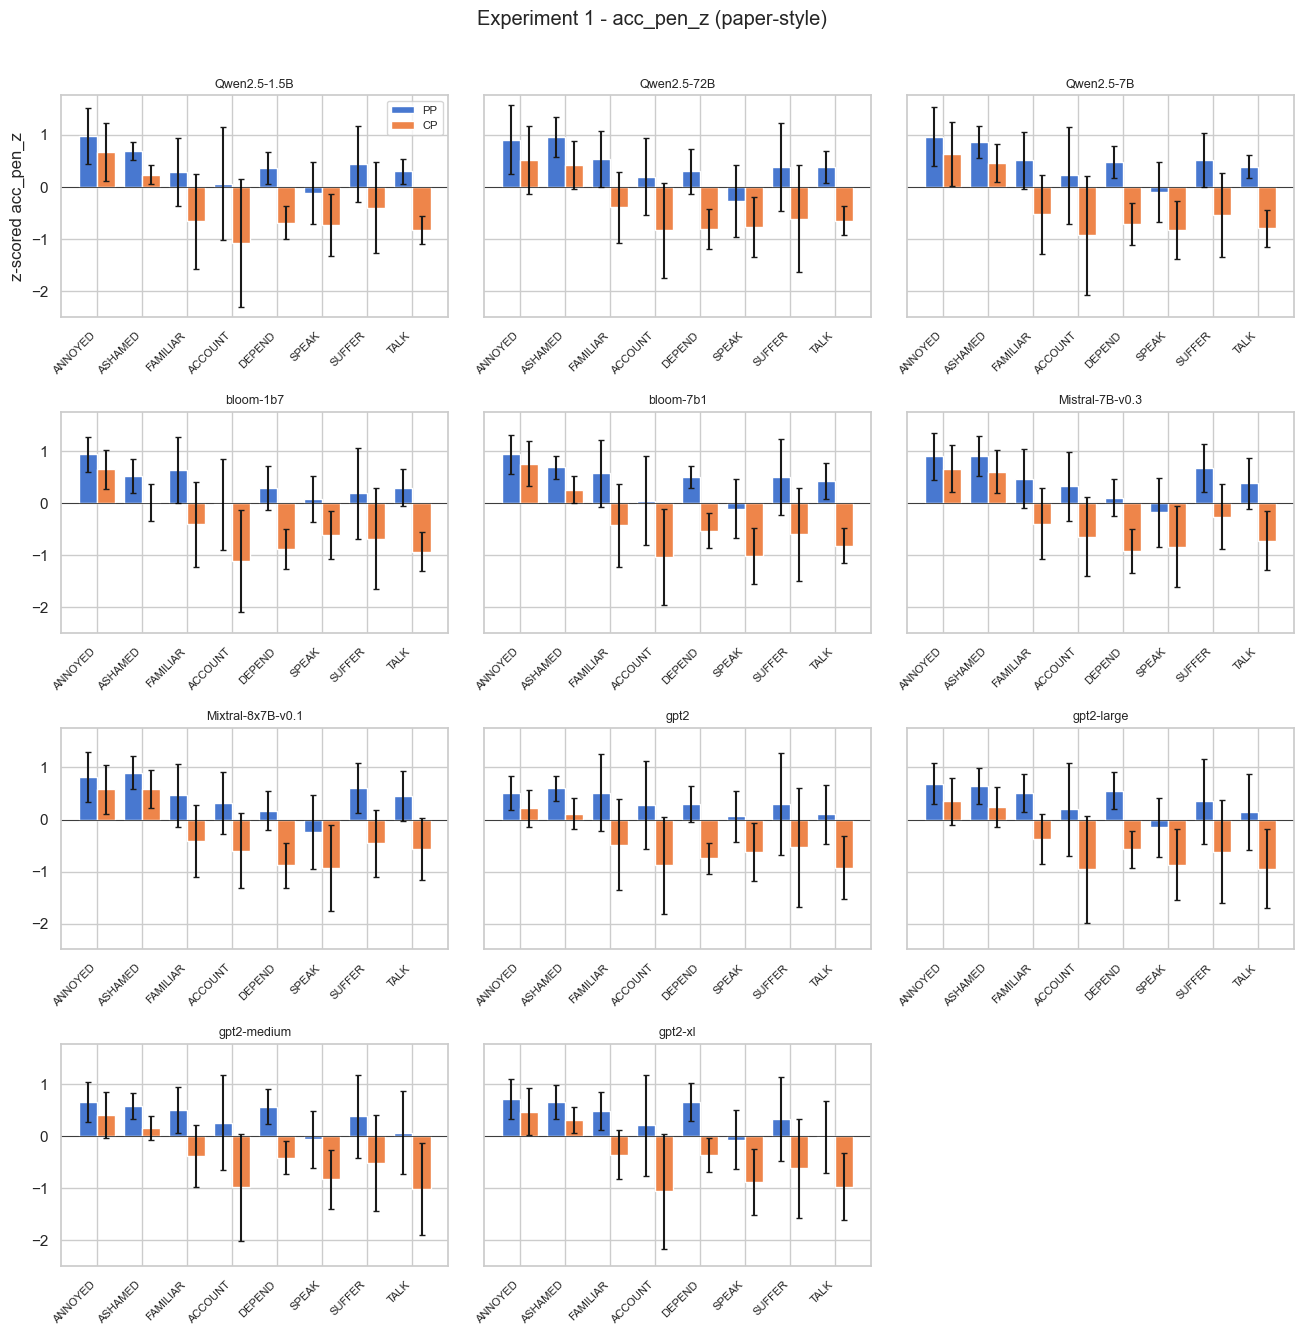

Saved: plots\paper_exp1_acc_pen_z.png


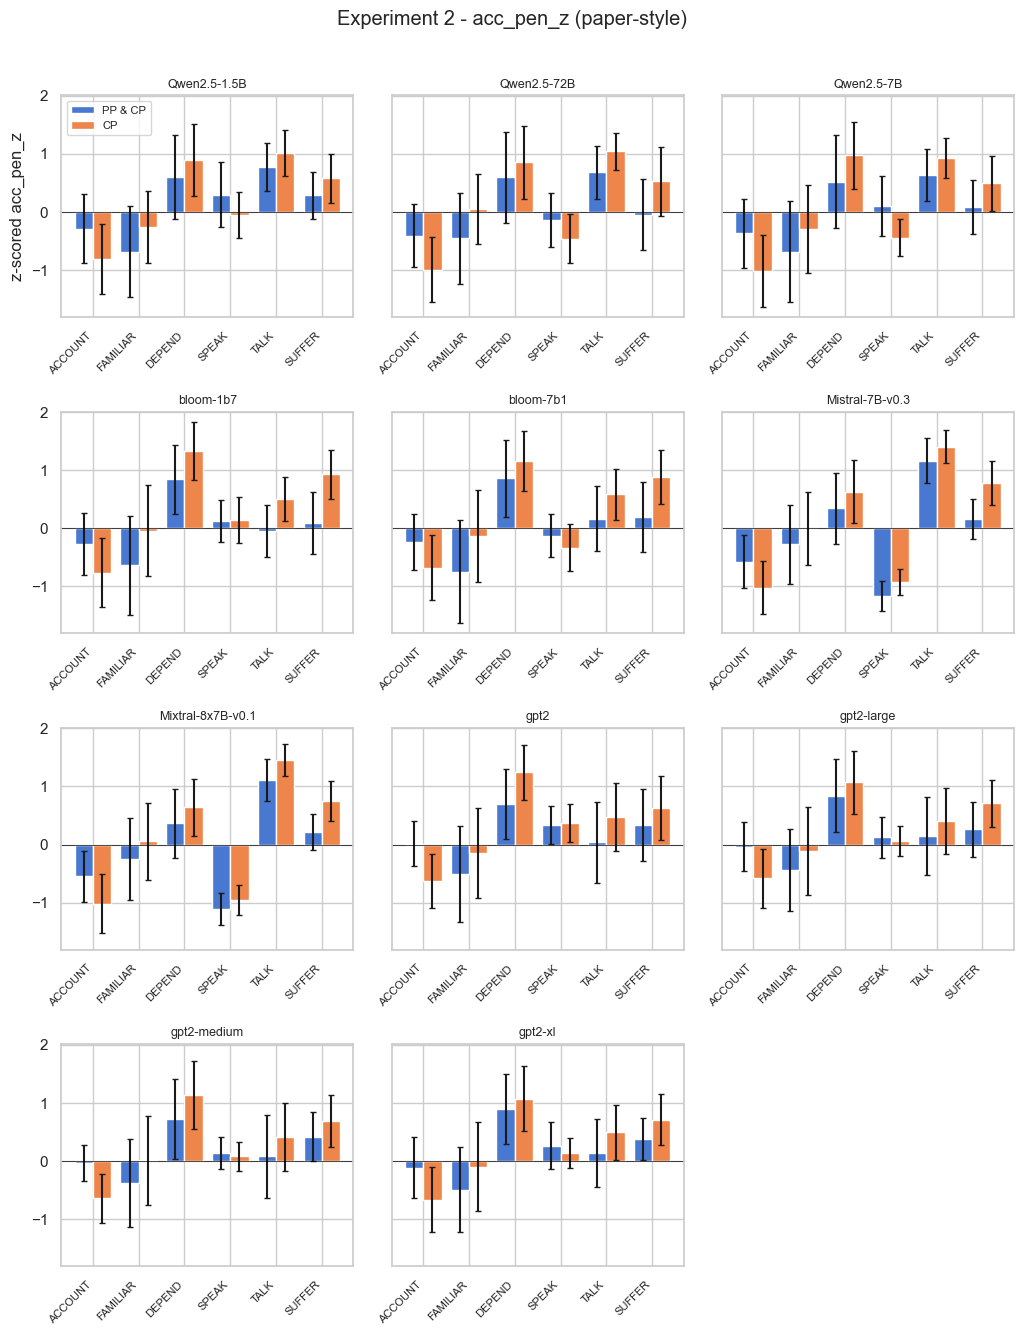

Saved: plots\paper_exp2_acc_pen_z.png


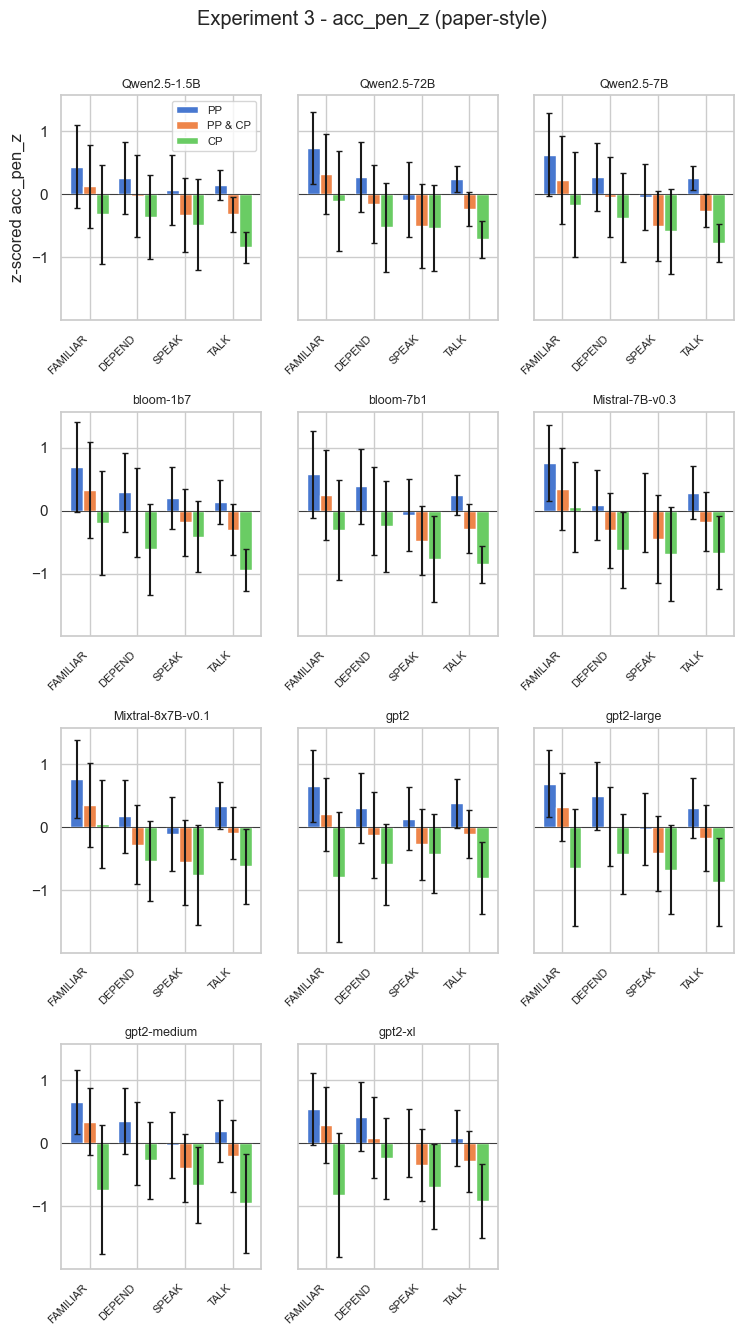

Saved: plots\paper_exp3_acc_pen_z.png


In [15]:
# 8.4 - Paper-style bar plots: one figure per (experiment, metric), one subplot per LLM

EXP_VARIANT_ORDER  = {1: ["PP", "CP"],     2: ["NC", "C"],          3: ["PP", "Co", "CP"]}
EXP_VARIANT_LABELS = {1: ["PP", "CP"],     2: ["PP & CP", "CP"],    3: ["PP", "PP & CP", "CP"]}
EXP_PRED_ORDER = {
    1: ["ANNOYED", "ASHAMED", "FAMILIAR", "ACCOUNT", "DEPEND", "SPEAK", "SUFFER", "TALK"],
    2: ["ACCOUNT", "FAMILIAR", "DEPEND",  "SPEAK",   "TALK",   "SUFFER"],
    3: ["FAMILIAR","DEPEND",   "SPEAK",   "TALK"],
}

def plot_paper_style(df, exp_num, metric_z):
    sub = df[df["experiment"] == exp_num].copy()
    models = sorted(sub["model"].unique())
    ncols  = 3
    nrows  = -(-len(models) // ncols)
    var_order  = EXP_VARIANT_ORDER[exp_num]
    var_labels = EXP_VARIANT_LABELS[exp_num]
    pred_order = EXP_PRED_ORDER[exp_num]

    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(2.0 + 1.4 * len(pred_order), 3.3 * nrows),
                             sharey=True)
    axes = np.array(axes).flatten()

    for ax, model in zip(axes, models):
        mdf = sub[sub["model"] == model]
        agg = (mdf.groupby(["subkind", "variant"])[metric_z]
                  .agg(mean="mean", sem="sem").reset_index())
        x = np.arange(len(pred_order))
        w = 0.8 / len(var_order)
        for i, v in enumerate(var_order):
            sel = agg[agg["variant"] == v].set_index("subkind").reindex(pred_order)
            vals = sel["mean"].to_numpy()
            errs = (sel["sem"].fillna(0).to_numpy()) * 1.96
            ax.bar(x + (i - (len(var_order) - 1) / 2) * w, vals, w,
                   yerr=errs, capsize=2, label=var_labels[i])
        ax.set_xticks(x)
        ax.set_xticklabels(pred_order, rotation=45, ha="right", fontsize=8)
        ax.axhline(0, color="black", linewidth=0.5)
        ax.set_title(model.split("/")[-1], fontsize=9)
    for ax in axes[len(models):]:
        ax.set_visible(False)
    axes[0].set_ylabel(f"z-scored {metric_z}")
    axes[0].legend(fontsize=8, loc="best")
    fig.suptitle(f"Experiment {exp_num} - {metric_z} (paper-style)", y=1.01)
    fig.tight_layout()
    fname = os.path.join(PLOT_DIR, f"paper_exp{exp_num}_{metric_z}.png")
    fig.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()
    return fname

for metric in ["acc_mean_z", "acc_sent_z", "acc_crit_z", "acc_pen_z"]:
    for exp_num in [1, 2, 3]:
        out = plot_paper_style(df, exp_num, metric)
        print(f"Saved: {out}")


### 8.5 LLM <-> paper agreement

For each metric, compute:
- **Sign match** - does the LLM's EMD have the same direction as the paper's?
- **Magnitude correlation** - Spearman rho between LLM EMDs (z-units) and paper EMDs (thermometer units).
- **Per-predicate agreement** - does the LLM reproduce the paper's qualitative split (e.g. annoyed/ashamed
  show no PP-vs-CP difference; depend/talk show large differences)?

The metric with the highest sign-match rate and rho is the best stand-in for human acceptability.


In [16]:
# 8.5 - Compare each metric's per-predicate EMDs against PAPER_EMD

def compare_to_paper(per_pred, exp_num):
    paper = PAPER_EMD[exp_num]
    label_map = PAPER_TO_DATA[exp_num]
    rows = []
    for model, gdf in per_pred[per_pred.experiment == exp_num].groupby("model"):
        for pred, contrasts in paper.items():
            for ckey, expected in contrasts.items():
                if ckey == "p":
                    continue
                a, b = ckey.split("_vs_")
                v1m, v2m = label_map[a], label_map[b]
                row = gdf[(gdf.predicate == pred) &
                          (((gdf.v1 == v1m) & (gdf.v2 == v2m)) |
                           ((gdf.v1 == v2m) & (gdf.v2 == v1m)))]
                if row.empty:
                    continue
                r = row.iloc[0]
                emd = r["EMD_z"] if r["v1"] == v1m else -r["EMD_z"]
                rows.append({
                    "model": model, "experiment": exp_num, "predicate": pred,
                    "contrast": ckey,
                    "paper_EMD": expected,
                    "llm_EMD_z": emd,
                    "sign_match": np.sign(emd) == np.sign(expected),
                    "p_paired": r["p_paired"],
                })
    return pd.DataFrame(rows)

comparisons = {}
ranking_rows = []
for metric_name, per_pred in paper_per_pred.items():
    cmp = pd.concat([compare_to_paper(per_pred, e) for e in [1, 2, 3]], ignore_index=True)
    cmp["metric"] = metric_name
    comparisons[metric_name] = cmp
    valid = cmp.dropna(subset=["paper_EMD", "llm_EMD_z"])
    rho = stats.spearmanr(valid["paper_EMD"], valid["llm_EMD_z"]).correlation if len(valid) >= 3 else np.nan
    pearson = valid[["paper_EMD", "llm_EMD_z"]].corr().iloc[0, 1] if len(valid) >= 3 else np.nan
    sign_pct = 100 * cmp["sign_match"].mean()
    ranking_rows.append({
        "metric":           metric_name,
        "n_contrasts":      len(cmp),
        "sign_match_pct":   sign_pct,
        "spearman_rho":     rho,
        "pearson_r":        pearson,
    })

ranking = pd.DataFrame(ranking_rows).set_index("metric").round(3)
print("Metric ranking (best-to-worst stand-in for human acceptability):")
display(ranking.sort_values(["sign_match_pct", "spearman_rho"], ascending=False))

def per_pred_summary(cmp):
    return (cmp.groupby(["experiment", "predicate", "contrast"])
               .agg(paper_EMD=("paper_EMD", "first"),
                    llm_mean=("llm_EMD_z", "mean"),
                    llm_sd=("llm_EMD_z", "std"),
                    sign_match_pct=("sign_match", lambda s: 100 * s.mean()),
                    n_models=("model", "nunique"))
               .round(3))

print("\nPer-predicate summary for the best metric:")
best_metric = ranking.sort_values(["sign_match_pct", "spearman_rho"], ascending=False).index[0]
display(per_pred_summary(comparisons[best_metric]))


Metric ranking (best-to-worst stand-in for human acceptability):


,n_contrasts,sign_match_pct,spearman_rho,pearson_r
metric,,,,
acc_pen,286,79.371,0.663,0.764
acc_mean,286,73.077,0.696,0.714
acc_crit,286,67.832,0.698,0.732
acc_sent,286,58.042,-0.036,0.106



Per-predicate summary for the best metric:


paper_EMD  llm_mean  llm_sd  sign_match_pct  \
experiment predicate contrast                                                  
1          ACCOUNT   CP_vs_PP        -6.64    -1.106   0.109         100.000   
           ANNOYED   CP_vs_PP         0.33    -0.282   0.059           0.000   
           ASHAMED   CP_vs_PP        -0.27    -0.418   0.076         100.000   
           DEPEND    CP_vs_PP        -8.44    -1.072   0.067         100.000   
           FAMILIAR  CP_vs_PP        -5.58    -0.934   0.073         100.000   
           SPEAK     CP_vs_PP       -10.74    -0.709   0.103         100.000   
           SUFFER    CP_vs_PP        -8.26    -0.954   0.092         100.000   
           TALK      CP_vs_PP       -10.04    -1.099   0.091         100.000   
2          ACCOUNT   PPCP_vs_CP       1.07     0.541   0.074         100.000   
           DEPEND    PPCP_vs_CP       4.29    -0.338   0.117           0.000   
           FAMILIAR  PPCP_vs_CP       2.59    -0.418   0.111           0.000   
           SPEAK     PPCP_vs_CP       3.77     0.111   0.232          63.636   
           SUFFER    PPCP_vs_CP       4.30    -0.481   0.185           0.000   
           TALK      PPCP_vs_CP       6.85    -0.350   0.095           0.000   
3          DEPEND    PPCP_vs_CP       4.32     0.358   0.104         100.000   
                     PP_vs_CP         7.05     0.740   0.119         100.000   
                     PP_vs_PPCP       2.73     0.381   0.064         100.000   
           FAMILIAR  PPCP_vs_CP       2.26     0.642   0.322         100.000   
                     PP_vs_CP         2.70     1.010   0.301         100.000   
                     PP_vs_PPCP       0.44     0.368   0.059         100.000   
           SPEAK     PPCP_vs_CP       4.08     0.206   0.092         100.000   
                     PP_vs_CP         6.86     0.609   0.076         100.000   
                     PP_vs_PPCP       2.78     0.402   0.033         100.000   
           TALK      PPCP_vs_CP       7.33     0.595   0.096         100.000   
                     PP_vs_CP         8.97     1.054   0.089         100.000   
                     PP_vs_PPCP       1.63     0.459   0.049         100.000   

                                 n_models  
experiment predicate contrast              
1          ACCOUNT   CP_vs_PP          11  
           ANNOYED   CP_vs_PP          11  
           ASHAMED   CP_vs_PP          11  
           DEPEND    CP_vs_PP          11  
           FAMILIAR  CP_vs_PP          11  
           SPEAK     CP_vs_PP          11  
           SUFFER    CP_vs_PP          11  
           TALK      CP_vs_PP          11  
2          ACCOUNT   PPCP_vs_CP        11  
           DEPEND    PPCP_vs_CP        11  
           FAMILIAR  PPCP_vs_CP        11  
           SPEAK     PPCP_vs_CP        11  
           SUFFER    PPCP_vs_CP        11  
           TALK      PPCP_vs_CP        11  
3          DEPEND    PPCP_vs_CP        11  
                     PP_vs_CP          11  
                     PP_vs_PPCP        11  
           FAMILIAR  PPCP_vs_CP        11  
                     PP_vs_CP          11  
                     PP_vs_PPCP        11  
           SPEAK     PPCP_vs_CP        11  
                     PP_vs_CP          11  
                     PP_vs_PPCP        11  
           TALK      PPCP_vs_CP        11  
                     PP_vs_CP          11  
                     PP_vs_PPCP        11

#### LLM vs paper EMD scatter (per metric)

One dot per (LLM, predicate, contrast). A metric that tracks the paper produces points that fall in
matching quadrants relative to (0, 0).


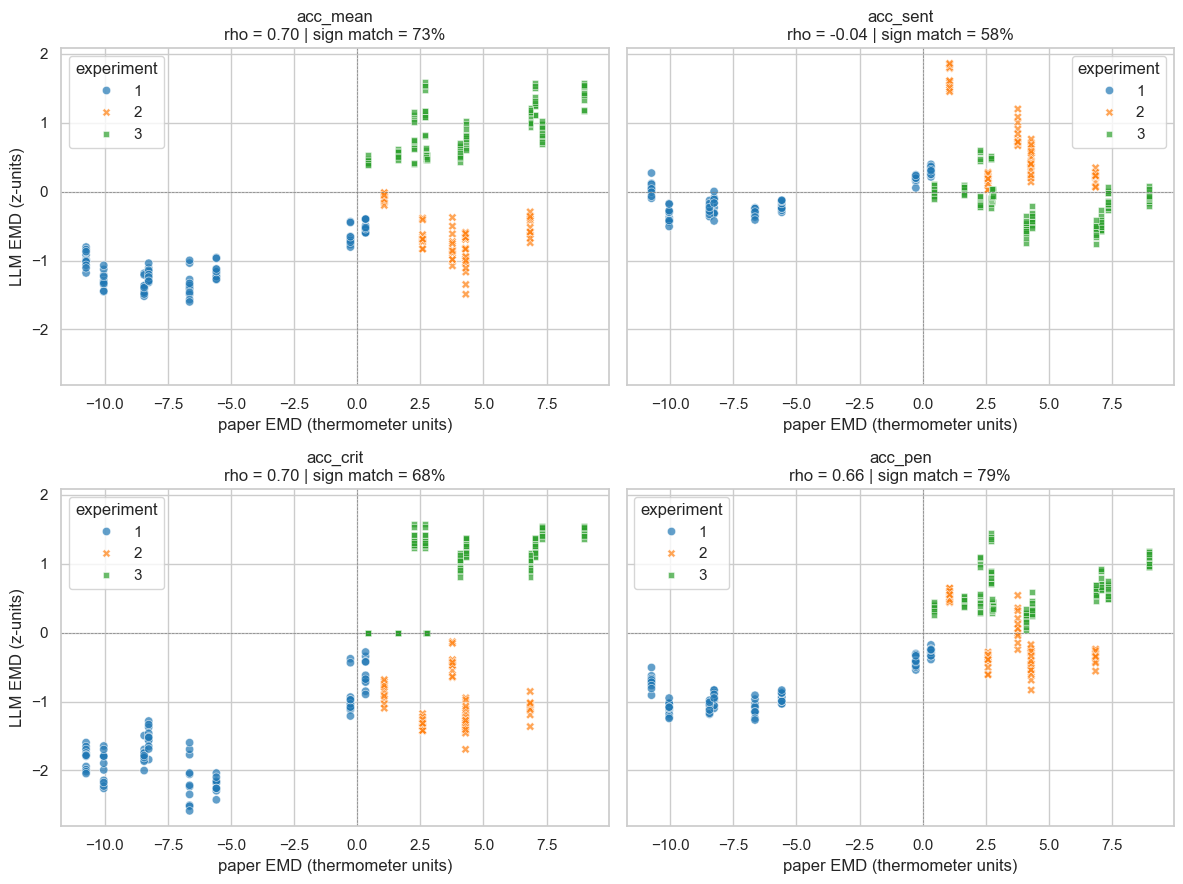

Saved: plots\paper_vs_llm_EMD_scatter.png


In [17]:
# Scatter: paper EMD (thermometer units) vs LLM EMD (z-units), per metric
fig, axes = plt.subplots(2, 2, figsize=(12, 9), sharey=True)
axes = axes.flatten()
for ax, (metric, cmp) in zip(axes, comparisons.items()):
    valid = cmp.dropna(subset=["paper_EMD", "llm_EMD_z"])
    if valid.empty:
        ax.set_title(f"{metric} (no data)")
        continue
    sns.scatterplot(data=valid, x="paper_EMD", y="llm_EMD_z",
                    hue="experiment", style="experiment", ax=ax, alpha=0.7,
                    palette="tab10")
    ax.axhline(0, color="grey", lw=0.5, ls="--")
    ax.axvline(0, color="grey", lw=0.5, ls="--")
    rho = stats.spearmanr(valid["paper_EMD"], valid["llm_EMD_z"]).correlation
    sign = 100 * (np.sign(valid["paper_EMD"]) == np.sign(valid["llm_EMD_z"])).mean()
    ax.set_title(f"{metric}\nrho = {rho:.2f} | sign match = {sign:.0f}%")
    ax.set_xlabel("paper EMD (thermometer units)")
axes[0].set_ylabel("LLM EMD (z-units)")
axes[2].set_ylabel("LLM EMD (z-units)")
fig.tight_layout()
fname = os.path.join(PLOT_DIR, "paper_vs_llm_EMD_scatter.png")
fig.savefig(fname, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {fname}")


### 8.6 Option (b) - anchor LLM scores to standard items A-E

The paper assigns letter grades by comparing each cell's mean to the means of standard items A-E
(Gerbrich et al. 2019). Those standard items aren't in the current `results/` files. The scaffold
below runs the 30 sentences through whichever surprisal pipeline you used for the experimental items,
producing `results/results_standard_items.csv`. Once that exists, the per-LLM A-E means can be
overlaid on the Figure 8.4 plots to assign letter grades. **Do not run** until `PIPELINE` is wired up
to your actual surprisal callable.


In [18]:
# 8.6 - Standard items A-E (paper appendix B.2). Wire up PIPELINE before running.

STANDARD_ITEMS = {
    "A": [
        "The patient fooled the dentist by pretending to be in pain.",
        "There's a statue in the middle of the square.",
        "The winter is very harsh in the North.",
        "The tired teacher drank a cup of tea in the staff room.",
        "It's nice to eat pizza and watch a film.",
        "A hammer is a useful thing in a tool box.",
    ],
    "B": [
        "Before every lesson the teacher must prepare their materials.",
        "Jack doesn't boast about his being elected chairman.",
        "John cleaned his motorbike with which cleaning cloth?",
        "The best thing about a sister is you can borrow her clothes.",
        "What I need to know is which witness identified which defendant.",
        "A thousand dollars are a lot of money to pay for a flight.",
    ],
    "C": [
        "Anna loves, but Linda hates, eating popcorn at the cinema.",
        "Most people like very much a cup of tea in the morning.",
        "The striker fouled deliberately the goalkeeper.",
        "What I want to know is which exam which student failed.",
        "You can't say that to me, who does most of the work here!",
        "The estate agent revealed him the whole plan to build a gas works.",
    ],
    "D": [
        "Who did he whisper that had unfairly condemned the prisoner?",
        "The old fisherman took her pipe out of mouth and began story.",
        "Which professor did you claim that the student really admires him?",
        "That boy had run away from home, who we saw in the bus.",
        "In southern Spain heavy rain falling only in the mountains.",
        "The author looked in the dictionary up the word.",
    ],
    "E": [
        "Historians wondering what cause is disappear civilization.",
        "Old man he work garden grow many flowers and vegetable.",
        "Student must read much book for they become clever.",
        "Crossing the wild seas Odysseus was meet some monster.",
        "Who did you wonder when Michael will introduce to his parents?",
        "The Spartans brave stood in line fight for freedom.",
    ],
}

def run_standard_items(pipeline, models):
    """Run all 30 standard sentences through pipeline(model_id, sentences) -> list[dict].

    Each dict should have keys: sentence, sentence_surprisal, mean_surprisal,
    tokens (JSON), token_surprisals (JSON). Same shape as the result CSVs.
    """
    out = []
    for model in models:
        for band, sentences in STANDARD_ITEMS.items():
            results = pipeline(model, sentences)
            for r, sent in zip(results, sentences):
                row = {"model": model, "band": band, "sentence": sent}
                row.update(r)
                out.append(row)
    return pd.DataFrame(out)

# To run (uncomment + replace with your actual surprisal callable):
# from pipeline_together import surprisals_for as PIPELINE   # placeholder
# std_df = run_standard_items(PIPELINE, sorted(df["model"].unique()))
# std_df.to_csv("results/results_standard_items.csv", index=False)

# Once results/results_standard_items.csv exists, this block recomputes letter-grade anchors:
_std_path = os.path.join(RESULTS_DIR, "results_standard_items.csv")
if os.path.exists(_std_path):
    std_df = pd.read_csv(_std_path)
    std_df["acc_mean"] = -std_df["mean_surprisal"]
    std_df["acc_sent"] = -std_df["sentence_surprisal"]
    std_df["acc_mean_z"] = std_df.groupby("model")["acc_mean"].transform(z_score_group)
    std_df["acc_sent_z"] = std_df.groupby("model")["acc_sent"].transform(z_score_group)
    band_means = (std_df.groupby(["model", "band"])
                        [["acc_mean_z", "acc_sent_z"]].mean().round(3))
    print("Standard-items band means (per model):")
    display(band_means)
else:
    print(f"No standard-items results yet ({_std_path}). "
          "Run run_standard_items(...) and rerun this cell.")


No standard-items results yet (results\results_standard_items.csv). Run run_standard_items(...) and rerun this cell.


### 8.7 Export paper-comparison summaries


In [19]:
# 8.7 - Save per-predicate analyses + paper comparisons
for m, per_pred in paper_per_pred.items():
    per_pred.to_csv(os.path.join(RESULTS_DIR, f"paper_per_predicate_{m}.csv"), index=False)
for m, cmp in comparisons.items():
    cmp.to_csv(os.path.join(RESULTS_DIR, f"paper_comparison_{m}.csv"), index=False)
ranking.to_csv(os.path.join(RESULTS_DIR, "paper_metric_ranking.csv"))
print("Saved per-predicate analyses, paper comparisons, and metric ranking to results/.")


Saved per-predicate analyses, paper comparisons, and metric ranking to results/.
